## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di esplorare, pulire e comprendere l'andamento temporale e spaziale dei crimini, applicando tecniche di **analisi di serie temporali e forecasting**, per prevedere l'evoluzione dei fenomeni criminali in determinati distretti o periodi.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, statsmodels, numpy, pmdarima e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione predittiva**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.


In [1]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pmdarima as pm

### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Successivamente, verranno visualizzate le informazioni generali sulla struttura del dataset per comprenderne la composizione e la qualità dei dati disponibili.

In [17]:
file_path = 'CrimeData.csv'
crime_data = pd.read_csv(file_path)

# Mostra le informazioni di base del DataFrame
crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285807 entries, 0 to 285806
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CrimeDate        285807 non-null  object 
 1   CrimeTime        285807 non-null  object 
 2   CrimeCode        285807 non-null  object 
 3   Location         284184 non-null  object 
 4   Description      285807 non-null  object 
 5   Inside/Outside   281611 non-null  object 
 6   Weapon           97396 non-null   object 
 7   Post             285616 non-null  float64
 8   District         285749 non-null  object 
 9   Neighborhood     284106 non-null  object 
 10  Location 1       284188 non-null  object 
 11  Total Incidents  285807 non-null  int64  
dtypes: float64(1), int64(1), object(10)
memory usage: 26.2+ MB


## **Descrizione del dataset**

Il dataset analizzato contiene **285.807 osservazioni** e **12 colonne**, ciascuna delle quali descrive un aspetto relativo a un singolo evento criminale registrato nella città di Baltimora.  
I dati coprono diverse dimensioni temporali, spaziali e categoriali, rendendoli adatti per analisi di tipo descrittivo, predittivo e temporale.

### **Struttura delle colonne**
| Colonna | Tipo | Descrizione |
|----------|------|-------------|
| **CrimeDate** | `object` | Data in cui il crimine è stato registrato. |
| **CrimeTime** | `object` | Ora dell’evento. |
| **CrimeCode** | `object` | Codice identificativo del tipo di reato. |
| **Location** | `object` | Indirizzo o descrizione del luogo in cui è avvenuto il crimine. Alcuni valori mancanti (≈0,6%). |
| **Description** | `object` | Descrizione testuale del tipo di crimine (es. “ROBBERY”, “ASSAULT”). |
| **Inside/Outside** | `object` | Indica se il crimine è avvenuto all’interno (“Inside”) o all’esterno (“Outside”). Alcuni valori mancanti (≈1,5%). |
| **Weapon** | `object` | Tipologia di arma utilizzata (es. “Firearm”, “Knife”). Alta percentuale di valori mancanti (~66%). |
| **Post** | `float64` | Numero del distretto di polizia (post) in cui è stato registrato il crimine. |
| **District** | `object` | Nome del distretto di polizia (es. “SOUTHERN”, “NORTHERN”). Pochi valori mancanti. |
| **Neighborhood** | `object` | Nome del quartiere di Baltimora in cui è avvenuto il crimine. Alcuni valori mancanti (≈0,6%). |
| **Location 1** | `object` | Coordinate geografiche (latitudine, longitudine) in formato stringa. |
| **Total Incidents** | `int64` | Numero totale di incidenti registrati per quella specifica voce (spesso pari a 1). |

### **Considerazioni preliminari**
Il dataset è **abbastanza completo**, con una percentuale di valori nulli limitata in quasi tutte le colonne tranne **Weapon**, che richiede attenzione nella fase di pulizia.  
I dati sono **prevalentemente categoriali e temporali**, il che li rende adatti per un'applicazione di **modelli di forecasting** sul numero di incidenti; 


### **Pulizia e preparazione dei dati**

Per poter effettuare un'analisi efficace, sono necessarie alcune operazioni preliminari di **data cleaning** e **trasformazione**:

1. **Gestione dei valori mancanti**
   - Le colonne `Location`, `Inside/Outside`, `Weapon`, `District` e    `Neighborhood` presentano una certa quantità di valori nulli.
   - Si sostituiranno i valori con una categoria "Unknown".

2. **Creazione della colonna temporale unificata**
   - Le colonne `CrimeDate` e `CrimeTime` saranno unite in un'unica colonna `Datetime`:
     ```python
     crime_data['Datetime'] = pd.to_datetime(crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], errors='coerce')
     ```

   - Questa nuova variabile temporale consentirà di:
     - ordinare gli eventi nel tempo (`sort_values('Datetime')`);
     - effettuare analisi stagionali o giornaliere;
     - eseguire resampling (su base giornaliera o settimanale).

3. **Analisi temporale e aggregazione**
   - Per studiare l'evoluzione dei crimini nel tempo, il dataset sarà aggregato per periodo:
     ```python
     crime_time_series = crime_data.set_index('Datetime').resample('W')['Total Incidents'].sum()
     ```
    
   - Questa operazione consente di generare una serie temporale settimanale, utile per il **forecasting del numero di crimini**.

4. **Verifica e coerenza dei dati temporali**
   - Controllare che i dati siano ordinati e coerenti nel tempo:
     ```python
     crime_data = crime_data.sort_values('Datetime').reset_index(drop=True)
     ```

In [18]:
# ==========================
# Gestione dei valori mancanti
# ==========================
cols_to_fill = ['Location', 'Inside/Outside', 'Weapon', 'District', 'Neighborhood']
for col in cols_to_fill:
    crime_data[col] = crime_data[col].fillna('Unknown')

print("\n--- Valori mancanti dopo il fill ---")
print(crime_data[cols_to_fill].isnull().sum())

# ==========================
# Creazione della colonna DateTime
# ==========================
crime_data['DateTime'] = pd.to_datetime(
    crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], 
    errors='coerce'
)

# Rimuovo righe con DateTime non valido
crime_data = crime_data.dropna(subset=['DateTime'])

# Ordino per data e reindicizzo
crime_data = crime_data.sort_values('DateTime').reset_index(drop=True)

# ==========================
# Estrazione di feature temporali
# ==========================
crime_data['Year'] = crime_data['DateTime'].dt.year
crime_data['Month'] = crime_data['DateTime'].dt.month
crime_data['Day'] = crime_data['DateTime'].dt.day
crime_data['Hour'] = crime_data['DateTime'].dt.hour
crime_data['DayOfWeek'] = crime_data['DateTime'].dt.day_name()

# ==========================
# Creazione della serie temporale aggregata (weekly)
# ==========================
crime_time_series = (
    crime_data
    .set_index('DateTime')
    .resample('W')['Total Incidents']
    .sum()
    .reset_index()
)

# ==========================
# Output
# ==========================
print("\n=== Dimensione dataset pulito ===")
print(f"Serie temporale settimanale: {crime_time_series.shape}")

print("\n=== Esempio serie temporale settimanale ===")
print(crime_time_series.head(5).to_string(index=False))

# Mostra le statistiche descrittive della serie temporale
print("\n=== Statistiche descrittive della serie temporale settimanale ===")
print(crime_time_series.describe())



--- Valori mancanti dopo il fill ---
Location          0
Inside/Outside    0
Weapon            0
District          0
Neighborhood      0
dtype: int64

=== Dimensione dataset pulito ===
Serie temporale settimanale: (307, 2)

=== Esempio serie temporale settimanale ===
  DateTime  Total Incidents
2011-01-02              281
2011-01-09              800
2011-01-16              750
2011-01-23              804
2011-01-30              667

=== Statistiche descrittive della serie temporale settimanale ===
                  DateTime  Total Incidents
count                  307       307.000000
mean   2013-12-08 00:00:00       917.247557
min    2011-01-02 00:00:00       281.000000
25%    2012-06-20 12:00:00       851.000000
50%    2013-12-08 00:00:00       932.000000
75%    2015-05-27 12:00:00      1003.000000
max    2016-11-13 00:00:00      1114.000000
std                    NaN       116.174862


## **Analisi esplorativa del dataset**

Si effettuerà una prima analisi visiva del dataset graficando l'andamento della serie temporale dei crimini a Baltimora, in modo tale da poter avanzare una prima ipotesi sulla stazionarietà della serie.

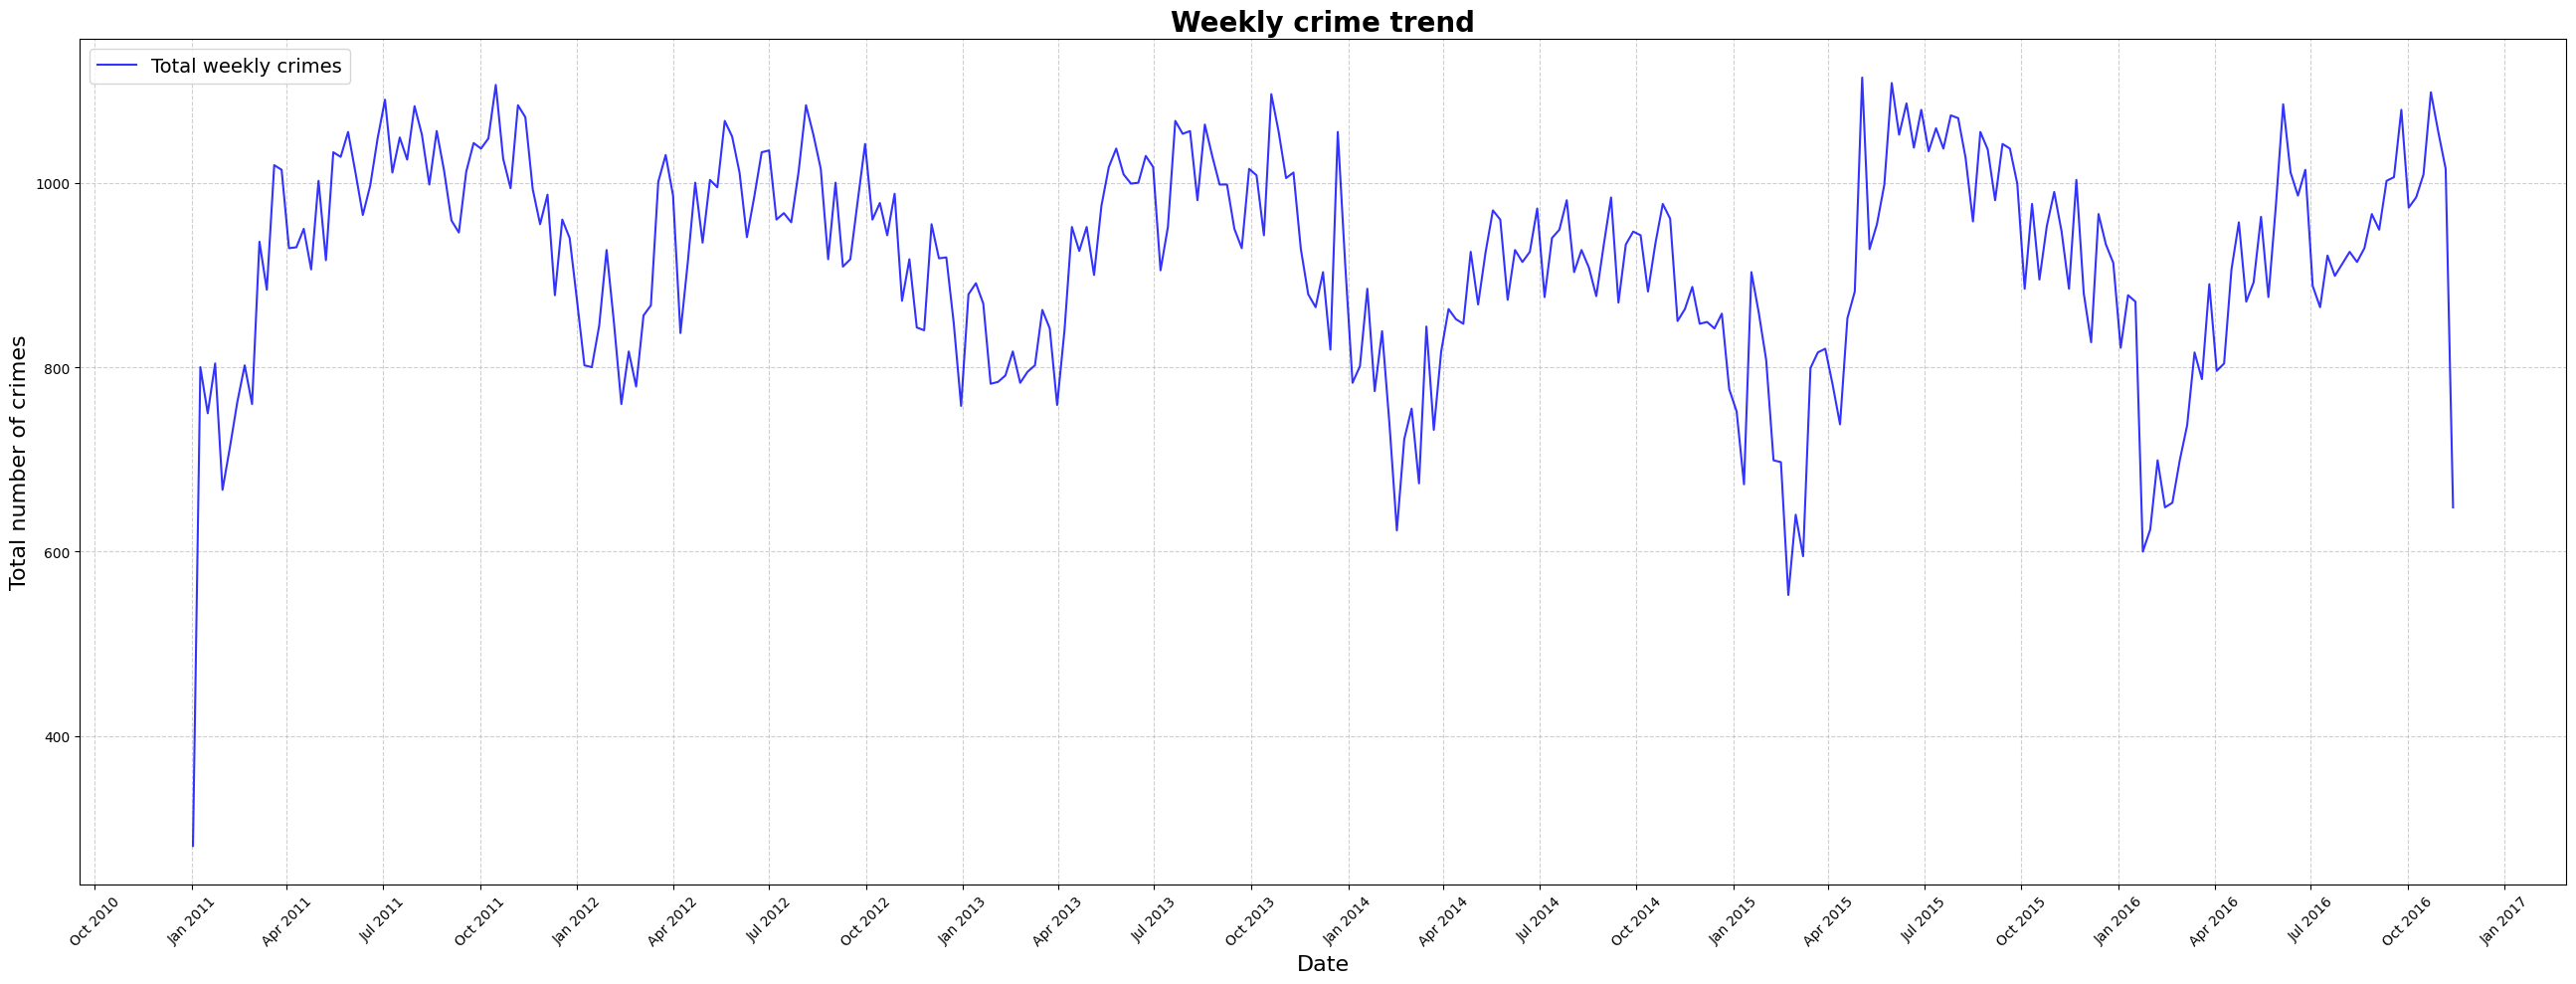

In [5]:
plt.figure(figsize=(26, 10))
plt.plot(
    crime_time_series['DateTime'],
    crime_time_series['Total Incidents'],
    label='Total weekly crimes',
    alpha=0.8,
    linewidth=1.5,
    color='blue'
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.title('Weekly crime trend', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Total number of crimes', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Osservando il grafico dell'**andamento settimanale dei crimini**, si possono notare alcune caratteristiche che suggeriscono che la serie **non è stazionaria**:

1. **Media non costante nel tempo**
   - Ci sono periodi in cui il numero totale di incidenti settimanali è mediamente più alto (ad esempio tra il 2011 ed il 2013, di nuovo intorno al 2015-2016).
   - Altri periodi mostrano una diminuzione visibile (ad esempio inizio 2015 ed inizio 2016).
   - Questo indica che la media varia nel tempo.

2. **Varianza non costante nel tempo**
   - L'ampiezza delle fluttuazioni  ("dispersione" dei valori) non è omogenea: in certi intervalli la variabilità sembra più elevata, mentre in altri le oscillazioni sono più contenute.
   - Anche la varianza, quindi, sembra cambiare nel tempo.

3. **Possibile stagionalità**
   - Il grafico mostra ciclicità annuale o semestrale: periodi ricorrenti in cui i crimini aumentano o diminuiscono, compatibili con **pattern stagionali** (ad esempio aumenti estivi o cali invernali).
   - Questo tipo di oscillazione periodica è tipico di una serie **non stazionaria** con componente stagionale.

4. **Valori più contenuti in certi intervalli**
   - Si notano cali marcati in corrispondenza di alcuni anni (ad esempio inizio 2015 e 2016), forse legati a fattori specifici (politiche di sicurezza, eventi eccezionali, cambiamenti nei dati).

In sintesi, la serie sembra **non essere stazionaria**, poiché **media e varianza variano nel tempo** e sono presenti **elementi di stagionalità**. Per analisi predittive è necessario **stazionarla** tramite differenziazione o rimozione della stagionalità.
Per effettuare un'analisi più approfondita, si decomporrà la serie nelle sue componenti stagionali, di trend e residuali.


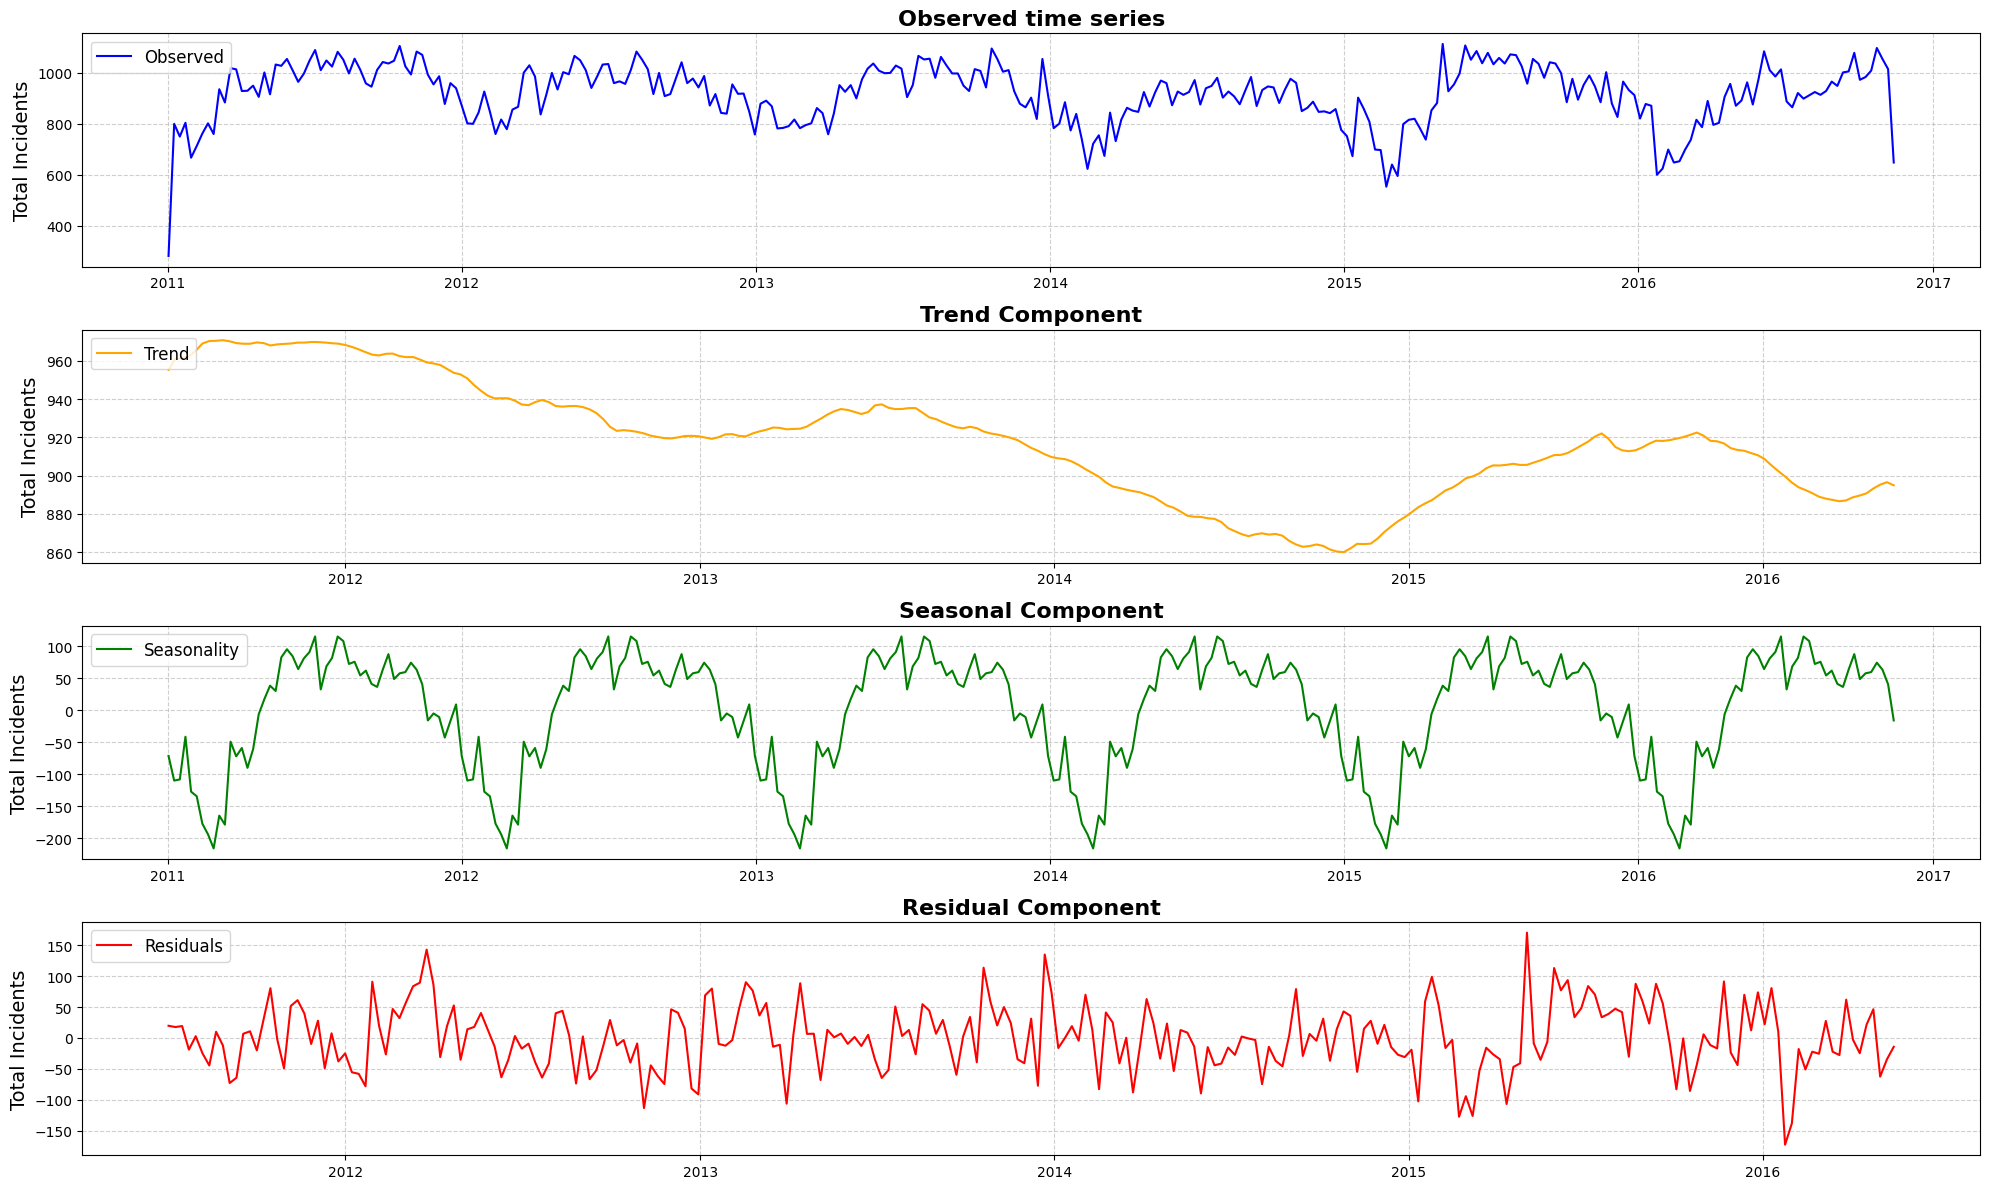

In [6]:
# Decomposizione della serie temporale
decomposition = seasonal_decompose(
    crime_time_series.set_index('DateTime')['Total Incidents'], 
    model='additive', 
    period=52
)
plt.figure(figsize=(20, 12))

# Osservato
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed', color='blue', linewidth=1.5)
plt.title('Observed time series', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Trend
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange', linewidth=1.5)
plt.title('Trend Component', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Stagionalità
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green', linewidth=1.5)
plt.title('Seasonal Component', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Residui
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red', linewidth=1.5)
plt.title('Residual Component', fontsize=16, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

1. **Componente di Trend**
   - Il trend mostra **una diminuzione graduale dal 2011 al 2014**, seguita da **una lieva risalita tra il 2015 e il 2016**.
   - Questo suggerisce che, nel lungo periodo, il **numero medio di crimini settimanali tende a calare leggermente**, ma con una ripresa negli ultimi anni del campione.
   - Quindi, **la media non è costante nel tempo**, confermando che la serie non è stazionaria in livello.

2. **Componente Stagionale**
   - Si osserva **una chiara periodicità annuale**, con oscillazioni regolari e simmetriche intorno allo zero.
   - La stagionalità è **molto marcata e stabile nel tempo**, indicando che i crimini tendono ad aumentare e diminuire in determinati periodi dell'anno (ad esempio più incidenti nei mesi estivi, meno in quelli invernali).
   - Questa regolarità suggerisce una **stagionalità fissa e ripetitiva**, il che è tipico di fenomeni sociali o ambienti influenzati da condizioni ricorrenti.

3. **Componente Residuale**
   - I residui oscillano intorno allo zero senza una struttura evidente, ma **non appaiono completamente bianchi**: in certi periodi (ad esempio 2015) sembrano più dispersi o con outlier.
   - Ciò indica che **parte della varianza non è spiegata** né dal trend né dalla stagionalità, ma non emergono pattern sistematici forti.
   - La varianza dei residui appare **piuttosto costante nel tempo**, un buon segno per modellazione successiva.

In sintesi, la serie **non è stazionaria in livello**, perché presenta **trend e stagionalità**. Dopo la rimozione del trend e della stagionalità o una differenziazione stagionale, i **residui potrebbero risultare stazionari** e quindi adatti a modelli successivi.

Per confermare l'ipotesi effettuiamo l'**ADF Test (Augmented Dickey-Fuller)** e misuriamo il **p-value**, che per serie stazionarie dovrebbe essere inferiore alla soglia di 0.05.

In [7]:
# Test di stazionarietà ADF
adf_test = adfuller(crime_time_series['Total Incidents'])

adf_results = pd.Series({"ADF Test Statistic": adf_test[0],
                         "p-value": adf_test[1],
                         "Used Lag": adf_test[2],
                         "Number of Observations": adf_test[3],
                         "Critical Value (1%)": adf_test[4]['1%'],
                         "Critical Value (5%)": adf_test[4]['5%'],
                         "Critical Value (10%)": adf_test[4]['10%']})

print("\n=== Risultati del test di stazionarietà ADF ===")
adf_results


=== Risultati del test di stazionarietà ADF ===


ADF Test Statistic         -4.303567
p-value                     0.000438
Used Lag                    9.000000
Number of Observations    297.000000
Critical Value (1%)        -3.452561
Critical Value (5%)        -2.871321
Critical Value (10%)       -2.571982
dtype: float64

In contrapposizione all'analisi effettuata, osservando i valori dell'ADF Test si può **rifiutare l'ipotesi nulla (H0)** con elevata confidenza (con un livello di confidenza superiore al 99%) e concludere che la serie è **stazionaria**. Tuttavia, ci sono alcune considerazioni da tenere in mente:
- **Statisticamente**, l'ADF dice che la serie può essere trattata come stazionaria.
- **Visivamente**, però, rimangono segnali di **trend e stagionalità**.

Si può quindi procedere con l'analisi dei **correlogrammi ACF e PACF** per stimare i parametri (p, d, q) del modello SARIMA.

### **Analisi dei correlogrammi**

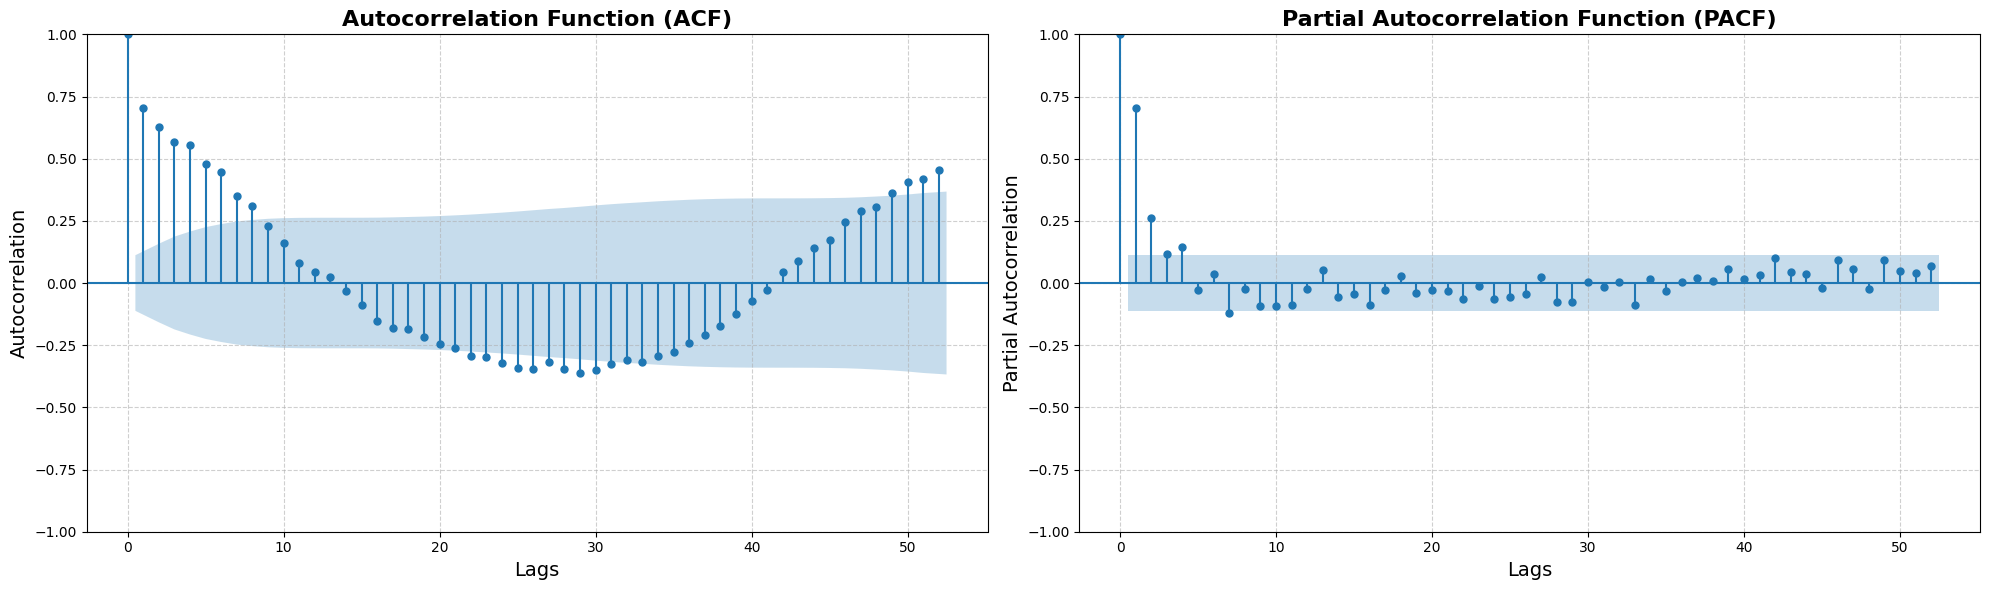

In [8]:
# Creazione dei grafici ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi = 100)

# Grafico ACF
plot_acf(crime_time_series['Total Incidents'], lags=52, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Lags', fontsize=14)
axes[0].set_ylabel('Autocorrelation', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafico PACF
plot_pacf(crime_time_series['Total Incidents'], lags=52, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Lags', fontsize=14)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Nonostante il test ADF indichi che la serie è stazionaria (quindi non ha un trend di lungo periodo esplosivo), i grafici mostrano che **c'è ancora una struttura molto forte** che deve essere modellata.

- **ACF**: l'ACF mostra la correlazione della serie con se stessa a vari ritardi (lags). La caratteristica più evidente è un pattern sinusoidale, che indica una forte stagionalità. Dato che il picco si ripete ogni ~52 lag, questo grafico ci dice che i crimini a Baltimora seguono un ciclo annuale molto preciso.

- **PACF**: isola la correlazione diretta tra un lag e l'altro, rimuovendo gli effetti intermedi. C'è un taglio netto già dai primi lag: il Lag 1 è molto alto (0.7), il Lag 2 è positivo ma molto più basso (circa 0.25). Dal Lag 3 in poi, la maggior parte dei punti rientra nell'area azzurra (l'intervallo di confidenza), il che significa che non sono statisticamente significativi (o sono rumore bianco).

- **Interpretazione**: Quando l'ACF decade lentamente (o in questo caso ondula) e la PACF si interrompe bruscamente dopo pochi lag, potrebbe essere il segnale di un processo Autoregressivo (AR), probabilmente un termine **AR(1)** o **AR(2)**.

Quindi, per quanto riguarda la **componente non stagionale** (p,d,q), probabilmente avremo dei valori:

- **p (AR)**: probabilmente 1 o 2, visto il taglio netto nella PACF dopo il lag 2;
- **d**: 0, poiché il test ADF ha detto che è stazionaria;
- **q (MA)**: probabilmente 0, poiché l'ACF non ha un taglio netto ma un decadimento.

Per quanto riguarda la **componente stagionale** (P,D,Q):

- **D**: anche se ADF dice che è stazionaria, il pattern ad onda è molto forte, quindi potrebbe essere utile provare una differenziazione stagionale.

In conclusione, prima di effettuare una differenziazione, si tenterà comunque di osservare cosa succede con la serie originale.

In [7]:
# Eseguiamo auto_arima specificando il periodo stagionale 'm'
sarima_model = pm.auto_arima(
    crime_time_series['Total Incidents'],  # La serie temporale
    seasonal=True,                         # Abilita la ricerca di un modello stagionale
    m=52,                                  # Il periodo a 52 settimane
    
    # Parametri per guidare la ricerca
    d=None,                                # Non forza una differenziazione semplice
    D=None,                                # Non forza una differenziazione stagionale
    test='adf',                             # Usa il test ADF per determinare d
    start_p=0, start_q=0,                  # Punto di partenza per i parametri non stagionali
    start_P=0, start_Q=0,                  # Punto di partenza per i parametri stagionali
    max_p=2, max_q=2,                      # Limite massimo per p e q
    max_P=2, max_Q=2,                      # Limite massimo per P e Q

    # Parametri per il controllo del processo
    trace=True,                            # Mostra i modelli che sta testando
    error_action='ignore',                 # Ignora i modelli che non convergono
    suppress_warnings=True,                # Sopprime i warning
    stepwise=True                          # Usa un approccio efficiente per la ricerca
)

# Stampa il sommario del modello migliore trovato
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3793.856, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3540.906, Time=6.25 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3633.306, Time=2.90 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=5066.424, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=3544.210, Time=0.06 sec
 ARIMA(1,0,0)(2,0,0)[52] intercept   : AIC=3536.478, Time=70.68 sec
 ARIMA(1,0,0)(2,0,1)[52] intercept   : AIC=3541.453, Time=86.73 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=3545.531, Time=5.19 sec
 ARIMA(0,0,0)(2,0,0)[52] intercept   : AIC=3785.813, Time=104.27 sec
 ARIMA(2,0,0)(2,0,0)[52] intercept   : AIC=3527.385, Time=88.68 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=3531.325, Time=6.78 sec
 ARIMA(2,0,0)(2,0,1)[52] intercept   : AIC=3528.778, Time=107.52 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=3534.167, Time=7.05 sec
 ARIMA(2,0,1)(2,0,0)[52] intercept   : AIC=3528.279, Time=115.83 sec
 ARIMA(1,0

Il modello migliore trovato con auto_arima per la **serie originale** è quello con parametri `p=2, d=0, q=0, P=2, D=0, Q=0`.

**Conferma della Stazionarietà**
- `d=0`:Il modello non ha applicato differenziazioni e la serie originale è stata accettata come stazionaria (grazie al test ADF).
- `D=0`: anche la componente stagionale è stabile e non richiede differenziazione.

**Struttura del Modello**

Il modello è puramente **AutoRegressivo (AR)**, sia a breve termine che stagionale.
- `AR(2) (Semplice)`: i coefficienti _ar.L1_ e _ar.L2_ sono significativi. Ciò significa che il numero di crimini della settimana corrente dipende fortemente dai crimini di **1 e 2 setimane fa**.
- `Seasonal AR(2) (Stagionale)`: i coefficienti _ar.S.L52_ e _ar.S.L104_ sono significativi. Significa che il modello guarda cos'è successo esattamente **1 e 2 anni fa (52-104 settimane)** per fare la previsione corrente.

Questo ha senso per i dati sul crimine: se la criminalità sale a breve termine, tende a restare alta per un po'; inoltre, c'è una forte ricorrenza annuale (ad esempio crimini estivi vs invernali).

**Diagnostica dei residui**:
- Ljung-Box (`Prob(Q) = 0.25`): si accetta l'ipotesi nulla, quindi i residui sono scorrelati (rumore bianco). Il modello ha catturato tutto il segnale temporale possibile.
- Jarque-Bera (`Prob(JB) = 0.00`): il p-value è minore di 0.05, mostrando che i residui **non seguono una distribuzione normale**. La `Kurtosis` alta (`9.39`) suggerisce che la distribuzione degli errori ha "code più pesanti", ovvero ci sono più valori estremi (outlier) di quanto ci si aspetterebbe. Sebbene non sia ideale, questo è molto comune nelle serie storiche reali e, per scopi di previsione, è meno grave della presenza di autocorrelazione.

Si può procedere con la diagnostica e l'analisi dei residui prodotti da tale modello, per assicurarci che non ci siano pattern particolari, cercando media e varianza costante.

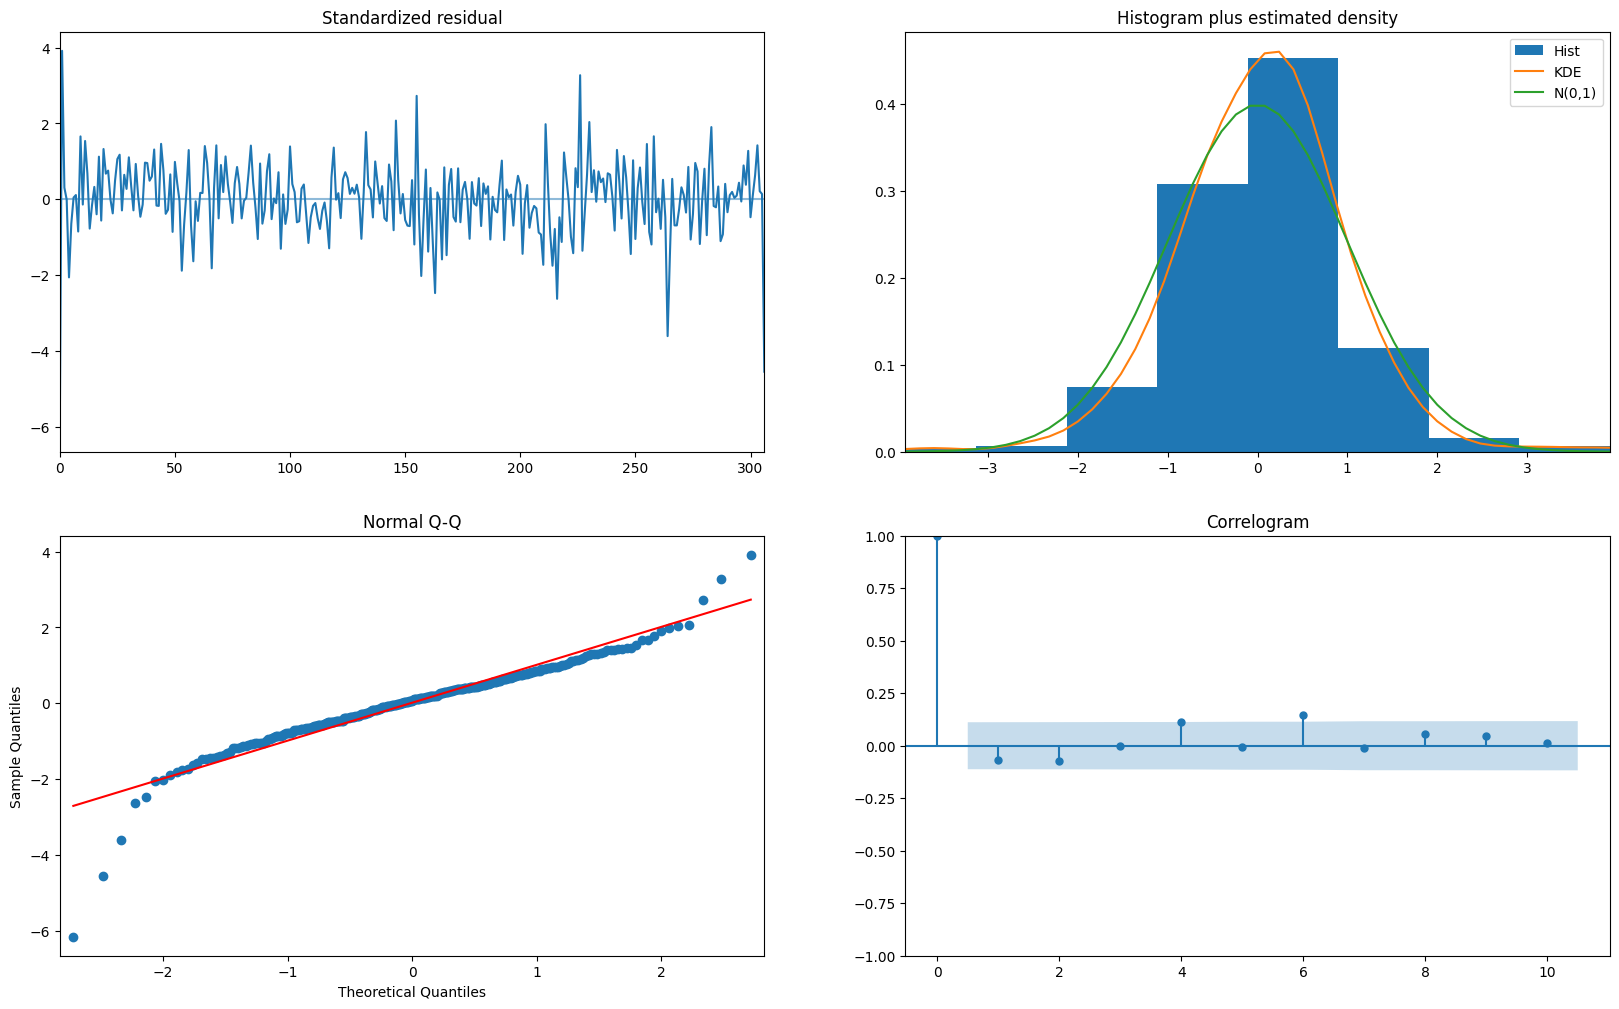

In [8]:
# Diagnostica del modello SARIMA
sarima_model.plot_diagnostics(figsize=(20, 12));

### **Diagnostica dei residui della serie originale**
1. **Standardized Residuals**
Questo grafico mostra gli errori del modello nel tempo, standardizzati in modo da avere una deviazione standard di 1.
   - I residui fluttuano in modo casuale attorno alla linea dello zero. Non c'è alcun trend, ciclo o pattern evidente. La varianza appare costante.
   - Il modello segue bene l'andamento generale (la media è zero), ma ci sono settimane specifiche (gli outlier) in cui il numero di crimini è stato alto o basso rispetto alla media. Questo è normale in una serie storica con dati reali.

2. **Histogram plus estimated density**
Questo grafico confronta la distribuzione dei residui (istogramma blu e curva KDE arancione) con una distribuzione normale perfetta (curva verde N(0,1)).
   - La curva arancione (KDE) è centrata sullo zero e ha una forma a campana, ma è leggermente più "appuntita" e alta rispetto alla curva normale verde ed è leggermente spostata verso destra.
   - Visivamente viene confermato il risultato del test di Jarque-Bera. I residui **non sono perfettamente normali**, ma sono molto vicini. La forma più appuntita è comune nei dati reali e non invalida il modello per scopi di previsione.

3. **Normal Q-Q Plot**
Questo grafico confronta i quantili dei residui (punti blu) con i quantili di una distribuzione normale teorica (linea rossa).
   - La stragrande maggioranza dei punti si allinea quasi perfettamente lungo la linea rossa. Si notano solo leggere deviazioni alle estremità, che corrispondono agli outlier.
   - Questo è un risultato eccellente e rafforza la conclusione precedente. Nonostante la non-normalità statistica, la distribuzione **si avvicina molto a una distribuzione normale** per la maggior parte dei valori.

4. **Correlogram (ACF dei Residui)**
Questo grafico mostra se gli errori del modello sono correlati tra loro a diversi lag.
   - **Nessuna** delle barre di autocorrelazione (ad eccezione del lag 0, che è sempre 1) **supera in modo significativo l'area di confidenza blu**.
   - Questo conferma visivamente il test di Ljung-Box (`Prob(Q) > 0.05`): quindi **non c'è alcuna autocorrelazione residua significativa**. Il modello ha catturato tutta la dipendenza temporale (sia a breve termine sia stagionale) presente nei dati.

## **Addestramento del modello**

Addestriamo il modello dividendo il dataset in 80% training e 20% testing, così da poter simulare un addestramento sugli anni di misurazione (7) e valutare i risultati su un intero anno.

C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Mean Absolute Error (MAE): 75.32
Root Mean Squared Error (RMSE): 100.55


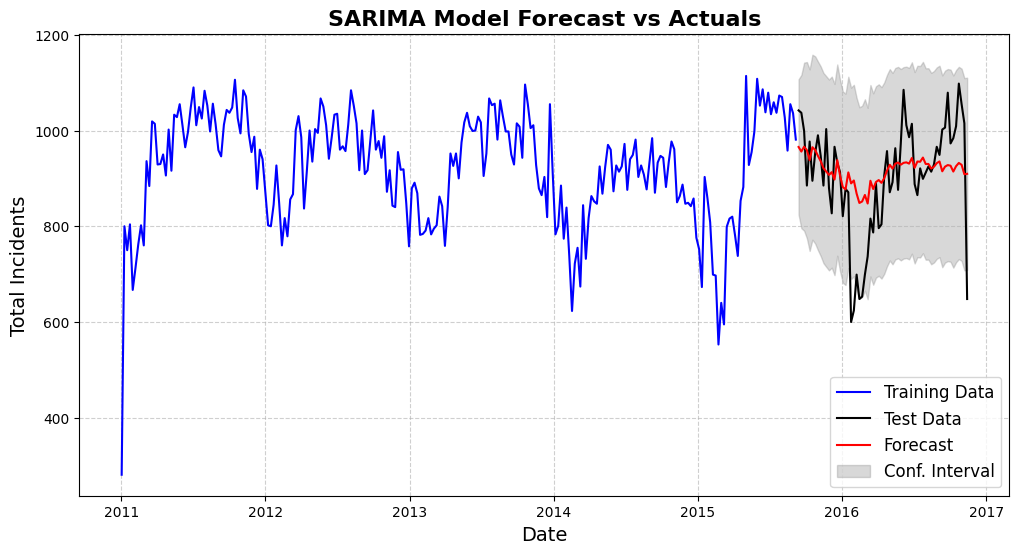

In [9]:
# Divisione in training e test set (80% training, 20% test)
train_size = int(len(crime_time_series) * 0.8)
train, test = crime_time_series[:train_size], crime_time_series[train_size:]

# Addestramento del modello SARIMA con i parametri trovati
model = SARIMAX(train['Total Incidents'], 
                order=(2, 0, 0), 
                seasonal_order=(2, 0, 0, 52),
                trend='c')
model_fit = model.fit(disp=False)

# Previsioni sul test set
forecast_object = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast_object.predicted_mean
forecast_ci = forecast_object.conf_int()

# Calcolo degli errori
mse = mean_squared_error(test['Total Incidents'], forecast_mean)
mae = mean_absolute_error(test['Total Incidents'], forecast_mean)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Plot dei risultati con intervalli di confidenza
plt.figure(figsize=(12, 6))
plt.plot(train['DateTime'], train['Total Incidents'], label='Training Data', color='blue')
plt.plot(test['DateTime'], test['Total Incidents'], label='Test Data', color='black')
plt.plot(test['DateTime'], forecast_mean, label='Forecast', color='red')
plt.fill_between(test['DateTime'], 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], label = 'Conf. Interval', color='grey', alpha=0.3)
plt.title('SARIMA Model Forecast vs Actuals', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Analisi Critica del Grafico**

- **Previsione (Linea rossa)**: Il modello riesce a individuare il **trend medio** e una vaga ciclicità stagionale, ma **fallisce nel catturare l'ampiezza dei picchi e delle valli**. La linea rossa appare "smorzata" rispetto alla realtà (linea nera), indicando che il modello tende a essere troppo conservativo. In pratica, sottostima i periodi di alta criminalità e sovrastima quelli di bassa.
- **Dati Reali (Linea nera)**: La varianza dei dati reali è molto più elevata di quanto previsto dal modello. Ci sono picchi improvvisi che la semplice storia passata non è sufficiente a spiegare.
- **Intervallo di confidenza (Area grigia)**: Sebbene i dati reali cadano spesso nell'intervallo, quest'ultimo è piuttosto ampio, segnale che il modello ha una certezza limitata.

**Analisi delle Metriche di Errore**
- **MAE (75.32) e RMSE (100.55)**: L'elevato divario tra MAE e RMSE conferma che ci sono **grandi errori puntuali** (gli outlier dei picchi che il modello non vede). 
- **Conclusione Preliminare**: Un modello puramente statistico (SARIMA) fornisce una **baseline accettabile, ma non sufficiente**. Riesce a dirci "più o meno" quanti crimini avverranno, ma non riesce a modellare la complessità e la variabilità settimana per settimana. 

**Strategia di Miglioramento: Forzare la Differenziazione Stagionale ($D=1$)**

Sebbene l'algoritmo `auto_arima` e i test di stazionarietà abbiano suggerito un modello senza differenziazioni ($D=0$), l'analisi visiva mostra una previsione eccessivamente conservativa ("smorzata") che tende a ritornare verso la media storica, fallendo nel raggiungere i picchi stagionali reali.

Per migliorare la capacità del modello di catturare l'ampiezza delle oscillazioni, una strategia efficace potrebbe essere **forzare manualmente una differenziazione stagionale (`D=1`)**, anche andando contro i test preliminari.
In questo scenario, il modello non cercherebbe più di prevedere il numero assoluto di crimini, ma la **differenza rispetto alla stessa settimana dell'anno precedente** ($Y_t - Y_{t-52}$).

Questo approccio comporta due potenziali benefici:
1.  **Maggiore Reattività**: Costringe il modello a replicare la "forma" dell'anno precedente, permettendogli di seguire meglio i picchi e le valli stagionali anziché appiattirsi.
2.  **Gestione di Trend Locali**: Aiuta a catturare eventuali cambiamenti nel livello base della criminalità che i coefficienti AR puri potrebbero perdere su lunghi orizzonti.

### **Analisi Serie Differenziata**

A questo punto, si procederà l'analisi effettuando due approcci di differenziazione:
- **Semplice**: per rimuovere il trend, con l'effetto di trasformare la serie che oscilla attorno ad una media costante, di fatto "appiattendo" il trend.
- **Stagionale**: per rimuovere pattern annuali o periodici, eliminando la dipendenza ciclica annuale; confrontando ogni settimana con la stessa settimana dell'anno prima, si annulla l'effetto sistematico legato a quel particolare periodo dell'anno.

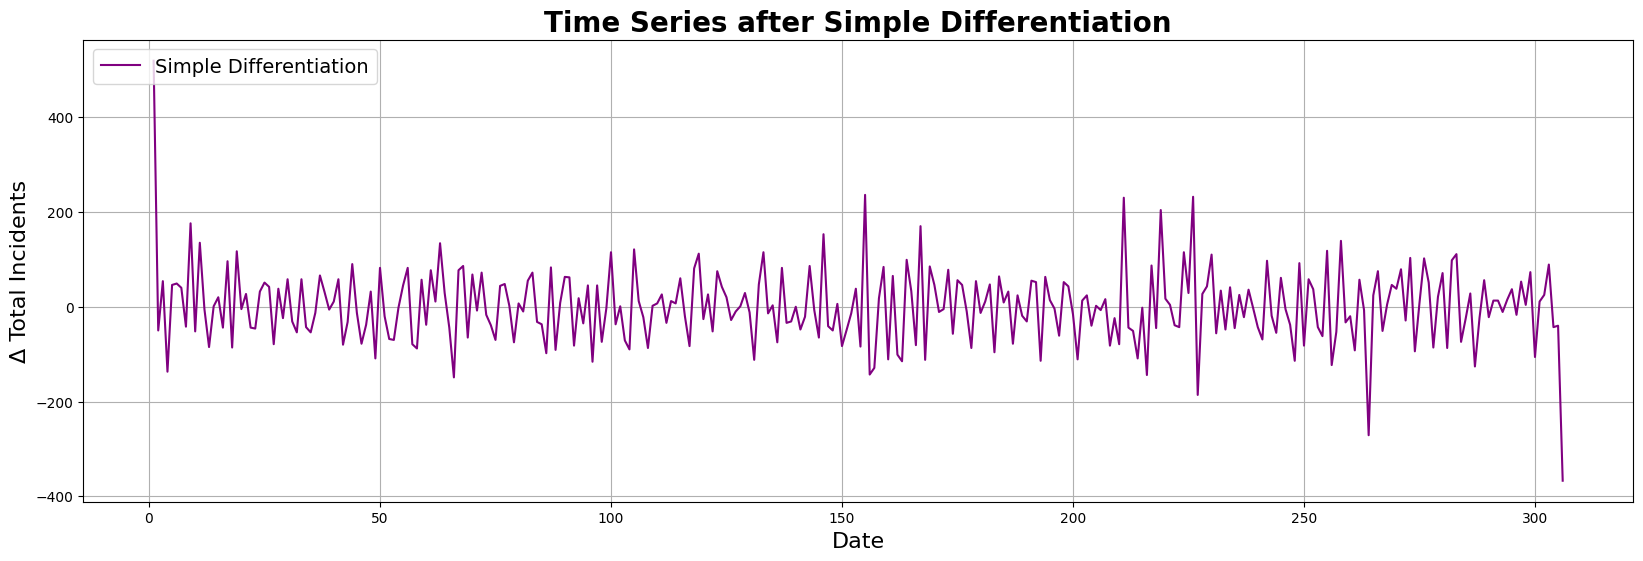

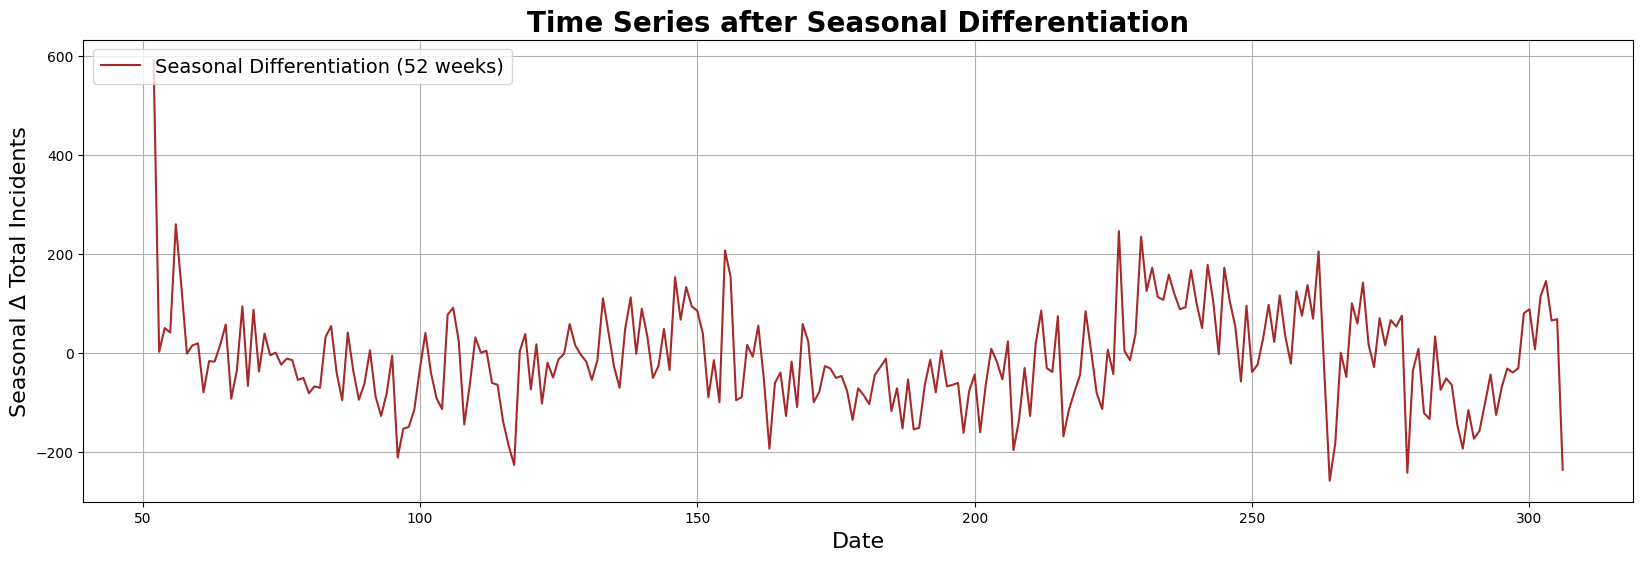


=== Risultati del test di stazionarietà ADF sulla serie differenziata semplice ===
ADF Test Statistic       -7.476872e+00
p-value                   4.887433e-11
Used Lag                  5.000000e+00
Number of Observations    3.000000e+02
Critical Value (1%)      -3.452337e+00
Critical Value (5%)      -2.871223e+00
Critical Value (10%)     -2.571929e+00
dtype: float64

=== Risultati del test di stazionarietà ADF sulla serie differenziata stagionale ===
ADF Test Statistic         -4.166292
p-value                     0.000751
Used Lag                    5.000000
Number of Observations    249.000000
Critical Value (1%)        -3.456888
Critical Value (5%)        -2.873219
Critical Value (10%)       -2.572994
dtype: float64


In [10]:
# Differenziazione semplice
crime_diff = crime_time_series['Total Incidents'].diff().dropna()

# Differenziazione stagionale (period=52 settimane)
crime_seasonal_diff = crime_time_series['Total Incidents'].diff(52).dropna()

# Grafico della differenziazione semplice
plt.figure(figsize=(20, 6))
plt.plot(crime_diff, label='Simple Differentiation', color='purple', linewidth=1.5)
plt.title('Time Series after Simple Differentiation', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Δ Total Incidents', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

# Grafico della differenziazione stagionale
plt.figure(figsize=(20, 6))
plt.plot(crime_seasonal_diff, label='Seasonal Differentiation (52 weeks)', color='brown', linewidth=1.5)
plt.title('Time Series after Seasonal Differentiation', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Seasonal Δ Total Incidents', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

# Test di stazionarietà ADF sulla serie differenziata
adf_test_diff = adfuller(crime_diff)
adf_test_seasonal_diff = adfuller(crime_seasonal_diff)
adf_results_diff = pd.Series({"ADF Test Statistic": adf_test_diff[0],
                         "p-value": adf_test_diff[1],
                         "Used Lag": adf_test_diff[2],
                         "Number of Observations": adf_test_diff[3],
                         "Critical Value (1%)": adf_test_diff[4]['1%'],
                         "Critical Value (5%)": adf_test_diff[4]['5%'],
                         "Critical Value (10%)": adf_test_diff[4]['10%']})

adf_results_seasonal_diff = pd.Series({"ADF Test Statistic": adf_test_seasonal_diff[0],
                         "p-value": adf_test_seasonal_diff[1],
                         "Used Lag": adf_test_seasonal_diff[2],
                         "Number of Observations": adf_test_seasonal_diff[3],
                         "Critical Value (1%)": adf_test_seasonal_diff[4]['1%'],
                         "Critical Value (5%)": adf_test_seasonal_diff[4]['5%'],
                         "Critical Value (10%)": adf_test_seasonal_diff[4]['10%']})
print("\n=== Risultati del test di stazionarietà ADF sulla serie differenziata semplice ===")
print(adf_results_diff)
print("\n=== Risultati del test di stazionarietà ADF sulla serie differenziata stagionale ===")
print(adf_results_seasonal_diff)

1. **Differenziazione semplice**
   - La statistica ADF (-7.48) è **molto più piccola** del valore critico al 1% (-3.45).
   - Il p-value è **praticamente zero**.
   - Conclusione: la serie differenziata semplice è **fortemente stazionaria**, il trend è stato completamente rimosso e ora la media e la varianza sono costanti nel tempo.

2. **Differenziazione stagionale (lag = 52 settimane)**
   - Anche qui la statistica ADF è **inferiore** al valore critico al 1% (-3.46).
   - Il p-value è ancora **molto basso** (<0.01).
   - Conclusione: la serie differenziata stagionale è anch'essa **stazionaria**, ma l'effetto è **meno marcato** rispetto alla differenziazione semplice.

In sintesi, la **differenziazione semplice** ha reso la serie fortemente stazionaria eliminando il trend principale, mentre la **differenziazione stagionale** ha rimosso le oscillazioni annuali, ma non riduce tanto la dipendenza come la prima. Entrambe le serie, quindi, risultano **statisticamente stazionarie**, ma per motivi diversi.

Per modelli come **SARIMA**, dove è utile catturare sia trend che stagionalità, una soluzione potrebbe essere **applicare entrambe le differenziazioni**, verificando di nuovo la stazionarietà e la stabilità visiva, dato che, in genere, la doppia differenziazione fornisce una serie finale stazionaria in media e varianza, pronta per il fitting di un modello ARIMA/SARIMA.

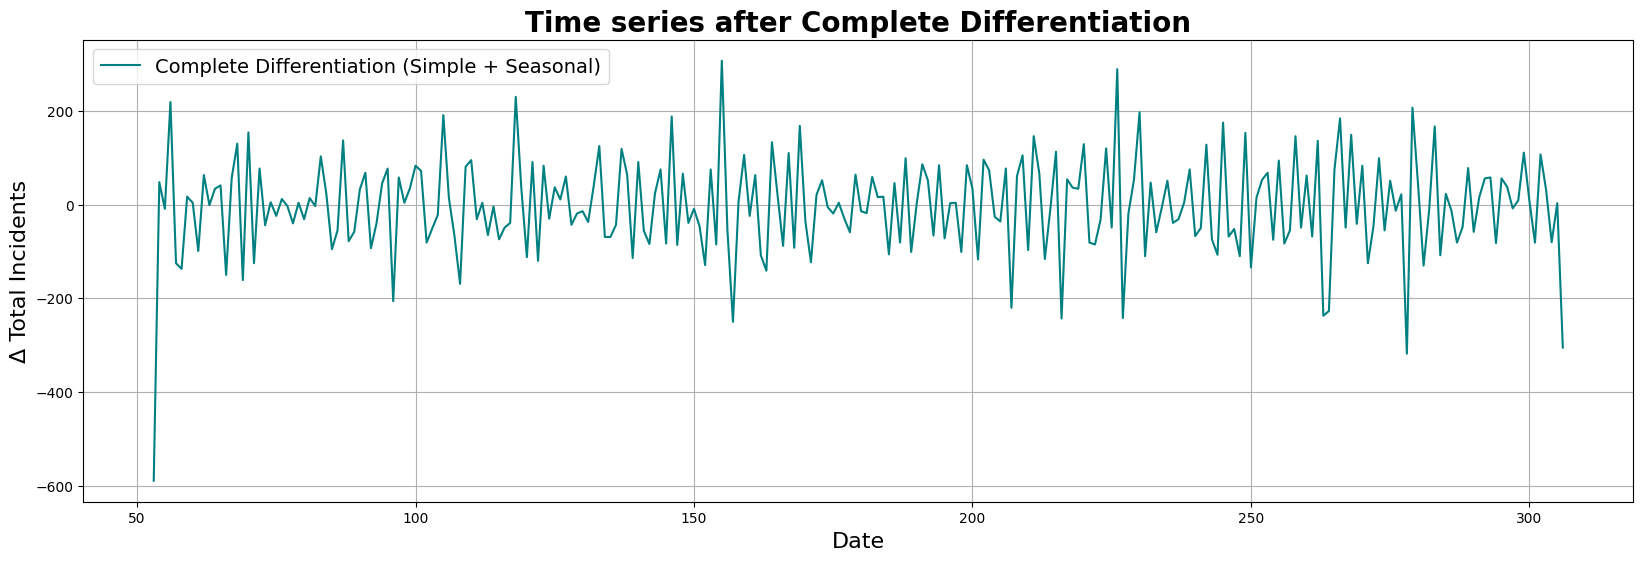

In [11]:
# Differenziazione completa (semplice + stagionale)
crime_diff_full = crime_time_series['Total Incidents'].diff().diff(52).dropna()

# Grafico della differenziazione completa
plt.figure(figsize=(20, 6))
plt.plot(crime_diff_full, label='Complete Differentiation (Simple + Seasonal)', color='teal', linewidth=1.5)
plt.title('Time series after Complete Differentiation', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Δ Total Incidents', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.show()

Nel grafico possiamo osservare che la serie differenziata completa (semplice + stagionale) oscilla chiaramente **intorno allo zero**, senza trend a lungo termine evidente. Inoltre, la varianza è **piuttosto costante**, con un'ampiezza delle oscillazioni relativamente consistenti lungo tutto l'asso temporale. Infine, non si osservano più pattern stagionali regolari.

In [12]:
# Test di stazionarietà ADF sulla serie completamente differenziata
adf_test_diff_full = adfuller(crime_diff_full)

# Risultati del test ADF
adf_results_diff_full = pd.Series({"ADF Test Statistic": adf_test_diff_full[0],
                         "p-value": adf_test_diff_full[1],
                         "Used Lag": adf_test_diff_full[2],
                         "Number of Observations": adf_test_diff_full[3],
                         "Critical Value (1%)": adf_test_diff_full[4]['1%'],
                         "Critical Value (5%)": adf_test_diff_full[4]['5%'],
                         "Critical Value (10%)": adf_test_diff_full[4]['10%']})

print("\n=== Risultati del test di stazionarietà ADF sulla serie completamente differenziata ===")
print(adf_results_diff_full)


=== Risultati del test di stazionarietà ADF sulla serie completamente differenziata ===
ADF Test Statistic       -1.157592e+01
p-value                   3.022940e-21
Used Lag                  4.000000e+00
Number of Observations    2.490000e+02
Critical Value (1%)      -3.456888e+00
Critical Value (5%)      -2.873219e+00
Critical Value (10%)     -2.572994e+00
dtype: float64


Osservando i risultati del test di stazionarietà ADF applicato alla serie differenzata completa, si può concludere che la serie è **pienamente stazionaria**. Si può quindi procedere con l'analisi dei **correlogrammi ACF e PACF** per stimare i parametri (p, d, q) del modello SARIMA.

### **Analisi dei correlogrammi**

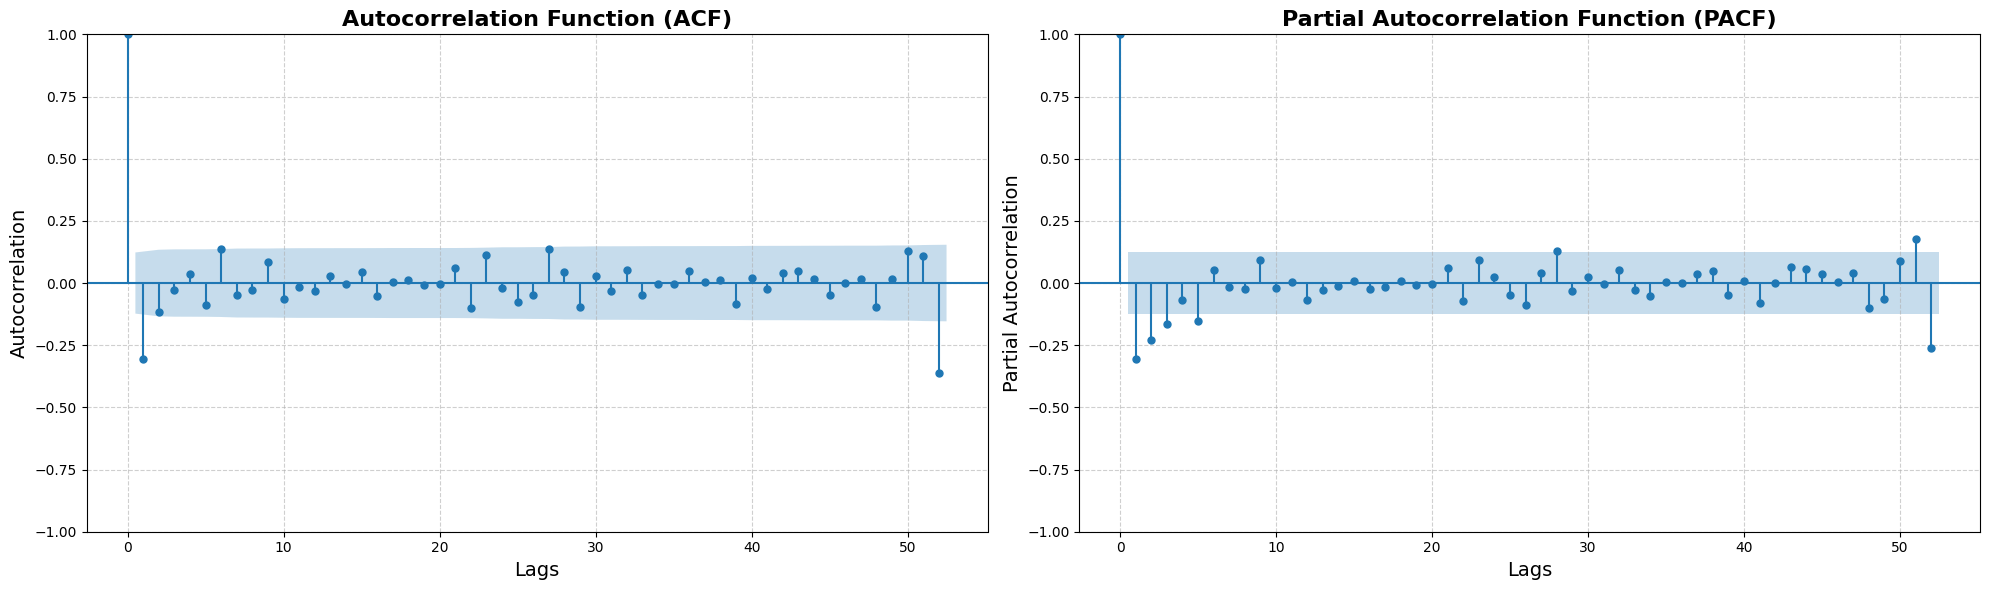

In [13]:
# Creazione dei grafici ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi = 100)

# Grafico ACF
plot_acf(crime_diff_full, lags=52, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Lags', fontsize=14)
axes[0].set_ylabel('Autocorrelation', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafico PACF
plot_pacf(crime_diff_full, lags=52, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Lags', fontsize=14)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### **Analisi delle Componenti non stagionali (p,q)**
Per identificare i parametri **p (ordine AR) e q (ordine MA)**, si osservano i primi lag dei grafici.
- **Grafico ACF**: c'è un picco negativo statisticamente significativo al **lag 1**. Subito dopo, i valori successivi cadono rapidamente all'interno della banda di confidenza (area azzurra). Questo pattern con un taglio netto e improvviso dopo il primo lag, è caratteristico di un **modello a Media Mobile (MA)**. L'ordine del modello è dato dall'ultimo lag significativo prima del taglio, suggerendo quindi un parametro `q = 1`.
- **Grafico PACF**: anche qui c'è un picco negativo significativo al **lag 1**, e i valori successivi tendono a cadere rapidamente all'interno della banda di confidenza. Un taglio netto nel PACF è tipico di un **modello Autoregressivo (AR)**, suggerendo un parametro `p = 1`.

Avendo indicazioni sia per un modello AR(1) sia per un MA(1) e analizzando entrambi i grafici, si osserva che il grafico ACF è molto netto e pulito, rendendo l'ipotesi di un **modello MA(1) (`q = 1`, `p = 0`)** leggermente più probabile e un ottimo punto di partenza.

#### **Analisi delle Componenti stagionali (P,Q)**
Per determinare i parametri stagionali `P` e `Q`, osserviamo i lag specificamente vicini al 52.
- **Grafico ACF**: si nota un **picco negativo statisticamente significativo al lag 52**. Questo picco è isolato, il che è un segnale molto forte per un modello di **Media Mobile Stagionale (SMA)**. Questo conferma la precedente ipotesi, suggerendo un valore di `Q = 1`.
- **Grafico PACF**: analogamente, si osserva un **picco negativo significativo al lag 52**. Anche questo picco sembra essere isolato, suggerendo un modello **Autoregressivo Stagionale (SAR)** e un valore di `P = 1`.



In [ ]:
# Eseguiamo auto_arima specificando il periodo stagionale 'm'
# e forzando la differenziazione semplice e stagionale.
sarima_model = pm.auto_arima(
    crime_time_series['Total Incidents'],  # La serie temporale
    seasonal=True,                         # Abilita la ricerca di un modello stagionale
    m=52,                                  # Il periodo a 52 settimane
    
    # Parametri per guidare la ricerca
    d=1,                                   # Forza una differenziazione semplice (per il trend)
    D=1,                                   # Forza una differenziazione stagionale
    start_p=0, start_q=0,                  # Punto di partenza per i parametri non stagionali
    start_P=0, start_Q=0,                  # Punto di partenza per i parametri stagionali
    max_p=2, max_q=2,                      # Limite massimo per p e q
    max_P=2, max_Q=2,                      # Limite massimo per P e Q

    # Parametri per il controllo del processo
    trace=True,                            # Mostra i modelli che sta testando
    error_action='ignore',                 # Ignora i modelli che non convergono
    suppress_warnings=True,                # Sopprime i warning
    stepwise=True                          # Usa un approccio efficiente per la ricerca
)

# Stampa il sommario del modello migliore trovato
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=3084.654, Time=0.57 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=3001.796, Time=16.69 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=inf, Time=57.68 sec
 ARIMA(1,1,0)(0,1,0)[52]             : AIC=3057.527, Time=1.07 sec
 ARIMA(1,1,0)(2,1,0)[52]             : AIC=2989.641, Time=60.63 sec
 ARIMA(1,1,0)(2,1,1)[52]             : AIC=2991.259, Time=176.38 sec
 ARIMA(1,1,0)(1,1,1)[52]             : AIC=2990.250, Time=118.76 sec
 ARIMA(0,1,0)(2,1,0)[52]             : AIC=inf, Time=57.87 sec
 ARIMA(2,1,0)(2,1,0)[52]             : AIC=2974.791, Time=87.72 sec
 ARIMA(2,1,0)(1,1,0)[52]             : AIC=2988.008, Time=22.12 sec
 ARIMA(2,1,0)(2,1,1)[52]             : AIC=2976.337, Time=208.68 sec
 ARIMA(2,1,0)(1,1,1)[52]             : AIC=2975.967, Time=142.43 sec
 ARIMA(2,1,1)(2,1,0)[52]             : AIC=2960.771, Time=156.23 sec
 ARIMA(2,1,1)(1,1,0)[52]             : AIC=2966.596, Time=42.47 sec
 ARIMA(2,1,1

Il modello migliore trovato con auto_arima per la **serie differenziata** è quello con parametri `p=1, d=1, q=1, P=2, D=1, Q=0`.

**Componente non stagionale**:
- `d = 1`: conferma che è stata necessaria una **differenziazione semplice** per rimuovere il trend.
- `p = 1`: il numero di incidenti di una settimana è influenzato dal numero di incidenti della **settimana precedente**.
- `q = 1`: il modello viene corretto anche in base all'**errore di previsione** commesso nella settimana precedente.

**Componente stagionale**:
- `D = 1`: conferma che sia stata necessaria una **differenziazione stagionale** per rimuovere il ciclo annuale.
- `P = 2`: il numero di incidenti di una settimana è influenzato non solo dal valore della **stessa settimana dell'anno precedente** (lag 52), ma anche da quello della **stessa settimana di due anni prima** (lag 104). Questo indica un pattern stagionale molto forte e persistente nel tempo.
- `Q = 0`: il modello non ha trovato necessario includere un termine di media mobile stagionale.

**Diagnostica dei residui**:
- Ljung-Box (`Prob(Q) = 0.25`): il p-value è maggiore di 0.05, indicando che i residui **non sono autocorrelati**. Il modello ha catturato con successo tutta la struttura temporale presente nei dati, lasciando solo "rumore bianco".
- Heteroskedasticity (`Prob(H) = 0.76`): il p-value è maggiore di 0.05, confermando che la varianza degli errori è **costante** nel tempo (omoschedasticità). Il modello è stabile e non ha periodi in cui commette errori sistematicamente più grandi o più piccoli.
- Jarque-Bera (`Prob(JB) = 0.00`): il p-value è minore di 0.05, mostrando che i residui **non seguono una distribuzione normale**, come per la serie originale.

Anche qui, si può procedere con la diagnostica e l'analisi dei residui prodotti da tale modello, per assicurarci che non ci siano pattern particolari, cercando media e varianza costante.

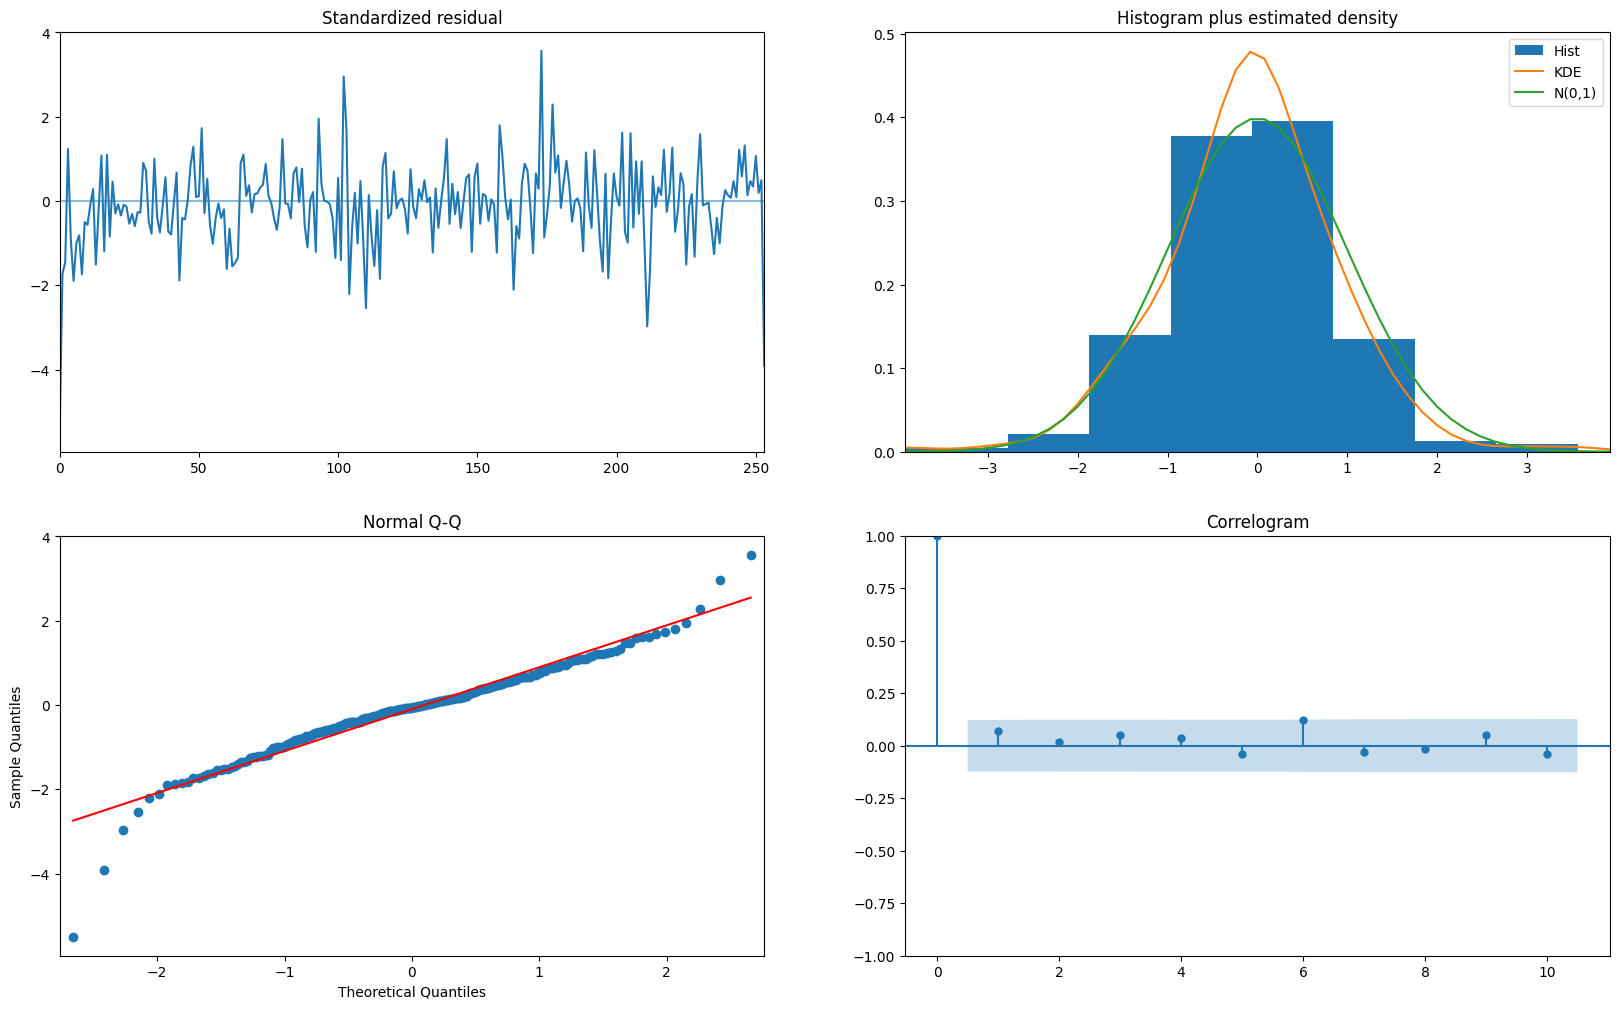

In [27]:
# Diagnostica del modello SARIMA
sarima_model.plot_diagnostics(figsize=(20, 12));

### **Diagnostica dei residui della serie differenziata**

Come per la serie originale, i risultati sono molto simili.

1. **Standardized Residuals**
Questo grafico mostra gli errori del modello nel tempo, standardizzati in modo da avere una deviazione standard di 1.
   - I residui fluttuano in modo casuale attorno alla linea dello zero. Non c'è alcun trend, ciclo o pattern evidente. La varianza appare costante.
   - Concludendo, questo è l'aspetto ideale del "rumore bianco", quindi il modello **ha estratto con successo tutta l'informazione prevedibile** dalla serie storica, lasciando solo un errore casuale ed imprevedibile.

2. **Histogram plus estimated density**
Questo grafico confronta la distribuzione dei residui (istogramma blu e curva KDE arancione) con una distribuzione normale perfetta (curva verde N(0,1)).
   - La curva arancione (KDE) è centrata sullo zero e ha una forma a campana, ma è leggermente più "appuntita" e alta rispetto alla curva normale verde.
   - Visivamente viene confermato il risultato del test di Jarque-Bera. I residui **non sono perfettamente normali**, ma sono molto vicini. La forma più appuntita è comune nei dati reali e non invalida il modello per scopi di previsione.

3. **Normal Q-Q Plot**
Questo grafico confronta i quantili dei residui (punti blu) con i quantili di una distribuzione normale teorica (linea rossa).
   - La stragrande maggioranza dei punti si allinea quasi perfettamente lungo la linea rossa. Si notano solo leggere deviazioni alle estremità, che corrispondono agli outlier.
   - Questo è un risultato eccellente e rafforza la conclusione precedente. Nonostante la non-normalità statistica, la distribuzione **si avvicina molto a una distribuzione normale** per la maggior parte dei valori.

4. **Correlogram (ACF dei Residui)**
Questo grafico mostra se gli errori del modello sono correlati tra loro a diversi lag.
   - **Nessuna** delle barre di autocorrelazione (ad eccezione del lag 0, che è sempre 1) **supera in modo significativo l'area di confidenza blu**.
   - Questo conferma visivamente il test di Ljung-Box (`Prob(Q) > 0.05`): quindi **non c'è alcuna autocorrelazione residua significativa**. Il modello ha catturato tutta la dipendenza temporale (sia a breve termine sia stagionale) presente nei dati.

## **Addestramento del modello**

Addestriamo il modello dividendo il dataset in 80% training e 20% testing, questa volta con la serie differenziata.

Mean Absolute Error (MAE): 76.28
Root Mean Squared Error (RMSE): 97.63


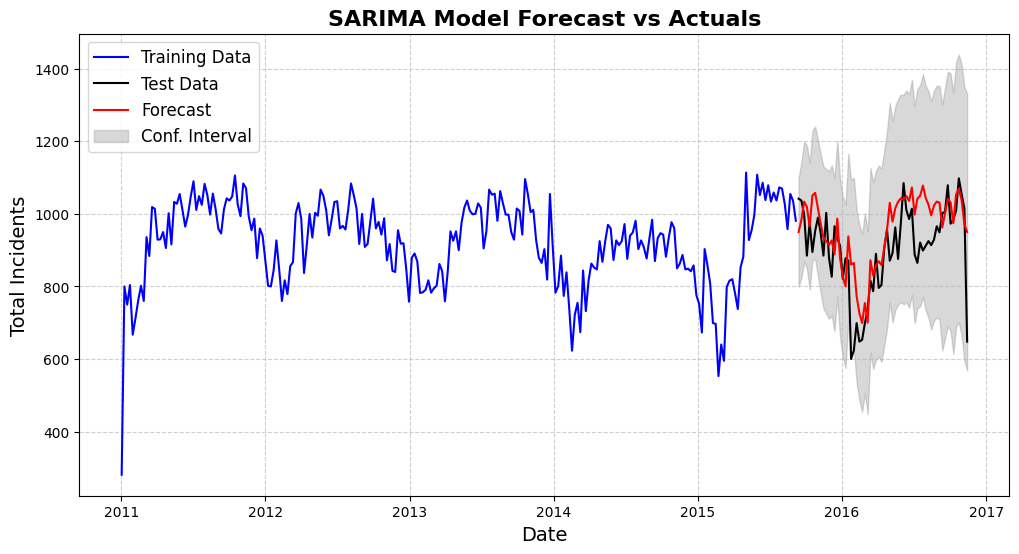

In [28]:
# Divisione in training e test set (80% training, 20% test)
train_size = int(len(crime_time_series) * 0.8)
train, test = crime_time_series[:train_size], crime_time_series[train_size:]

# Addestramento del modello SARIMA con i parametri trovati
model = SARIMAX(train['Total Incidents'], 
                order=(1, 1, 1), 
                seasonal_order=(2, 1, 0, 52),
                trend='n')
model_fit = model.fit(disp=False)

# Previsioni sul test set
forecast_object = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast_object.predicted_mean
forecast_ci = forecast_object.conf_int()

# Calcolo degli errori
mse = mean_squared_error(test['Total Incidents'], forecast_mean)
mae = mean_absolute_error(test['Total Incidents'], forecast_mean)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Plot dei risultati con intervalli di confidenza
plt.figure(figsize=(12, 6))
plt.plot(train['DateTime'], train['Total Incidents'], label='Training Data', color='blue')
plt.plot(test['DateTime'], test['Total Incidents'], label='Test Data', color='black')
plt.plot(test['DateTime'], forecast_mean, label='Forecast', color='red')
plt.fill_between(test['DateTime'], 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], label = 'Conf. Interval', color='grey', alpha=0.3)
plt.title('SARIMA Model Forecast vs Actuals', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Analisi del Grafico (Serie Differenziata)**

Analizzando il grafico del modello SARIMAX sulla serie differenziata, emergono differenze sostanziali rispetto al modello precedente:

- **Previsione (Linea rossa)**: a differenza del modello sulla serie originale (che appariva "piatto" e conservativo), qui la linea di previsione è **visivamente più dinamica e reattiva**, mostrando oscillazioni marcate. Tuttavia, a un'analisi attenta, si nota un evidente effetto di **ritardo di fase** (*lagging*): il modello tende a replicare i picchi e le valli della settimana precedente con un leggero ritardo, finendo per "inseguire" il dato reale piuttosto che anticiparlo.
- **Intervallo di confidenza (Area grigia)**: rimane ampio, simile al modello precedente. Questo indica che, nonostante la stazionarietà tecnica sia stata raggiunta, l'incertezza intrinseca del rumore non è stata ridotta significativamente.

**Analisi delle Metriche di Errore**
Le metriche d'errore confrontate con il modello precedente, descrivono che:

- **MAE (Mean Absolute Error): 76.28**. Il valore è **praticamente identico** (lievemente peggiorato) rispetto al modello sulla serie originale (75.32). Questo conferma che la maggiore reattività visiva non si è tradotta in una maggiore precisione puntuale: l'errore commesso nel prevedere un picco in ritardo (quando il dato reale sta già scendendo) annulla i benefici della maggiore volatilità.
- **RMSE (Root Mean Squared Error): 97.63**. si osserva un miglioramento marginale rispetto al precedente (100.55). La riduzione dell'RMSE suggerisce che il modello riesce a gestire leggermente meglio alcuni valori estremi, ma il divario con il MAE (circa 21) rimane significativo.

**Conclusione**: Questo risultato dimostra un concetto fondamentale nel forecasting: **la stazionarietà statistica è una condizione necessaria ma non sufficiente** per una buona previsione. Il modello differenziato ha corretto la struttura teorica dei dati, ma non disponendo di informazioni esterne, può solo basarsi sull'inerzia passata.

### **Miglioramento del Modello SARIMAX: Feature Engineering e Variabili Esogene**

Per potenziare la capacità predittiva del modello SARIMAX, si introdurranno nuove **variabili esogene**. L'obiettivo è fornire al modello informazioni contestuali che vadano oltre il semplice andamento storico del numero di incidenti, aiutandolo a interpretare meglio le fluttuazioni (es. picchi stagionali o trend recenti).

#### **Selezione e Trasformazione delle Variabili**

Sono state selezionate e costruite le seguenti feature, ponendo particolare attenzione al **ritardo temporale (lag)**. Per prevedere gli incidenti della settimana $t$, si utilizzeranno i dati disponibili fino alla settimana $t-1$, garantendo che il modello sia utilizzabile in uno scenario reale di previsione.

1.  **Variabili di Composizione del Crimine (Lagged)**
    * `lag_firearm_rate`: la percentuale di crimini con arma da fuoco registrata nella settimana precedente.
    * `lag_inside_rate`: la percentuale di crimini avvenuti in ambienti chiusi (*Inside*) nella settimana precedente.
    * La composizione qualitativa del crimine spesso anticipa le variazioni quantitative. Ad esempio, un aumento della violenza armata o uno spostamento verso crimini all'interno (spesso legati al meteo o a dinamiche sociali) possono essere precursori di un cambiamento nel volume totale degli incidenti. Poiché si calcola il tasso aggregando flag binari (0/1) dal dataset grezzo, si ottiene una misura precisa della frequenza relativa.

2.  **Variabili di Trend Recente (Rolling & Lagged)**
    * `lag_rolling_mean`: la media mobile degli incidenti delle ultime 4 settimane (traslata di 1).
    * **Razionale**: Questa variabile cattura l'inerzia del fenomeno. Se il trend dell'ultimo mese è in crescita, è probabile che la settimana successiva segua quella direzione. L'uso della media mobile aiuta a filtrare il rumore settimanale, fornendo al modello un segnale di trend più pulito.

3.  **Variabili di Calendario (Stagionalità)**
    * `month`: il mese dell'anno.
    * `is_summer`: indicatore binario per i mesi estivi (Giugno, Luglio, Agosto).
    * La criminalità ha una forte componente stagionale. L'estate, con più attività all'aperto, turismo e scuole chiuse, tende a mostrare pattern differenti rispetto all'inverno. Queste variabili aiutano il modello a regolare le aspettative in base al periodo dell'anno.

#### **Implementazione Tecnica**
Per evitare errori di indicizzazione e garantire la correttezza matematica, le percentuali (`rate`) sono state calcolate partendo dal dataset grezzo (`crime_data`), trasformando le categorie in flag numerici (0/1) e calcolandone la media durante il ricampionamento settimanale.

In [ ]:
# Copia del DataFrame originale
df = crime_time_series.copy()

# Crea flag numerici per le variabili categoriche
crime_data['is_firearm'] = (crime_data['Weapon'] == 'Firearm').astype(int)
crime_data['is_inside'] = (crime_data['Inside/Outside'] == 'Inside').astype(int)

# Aggregazione settimanale con le nuove variabili
crime_weekly = (
    crime_data.set_index('DateTime')
    .resample('W')
    .agg({
        'Total Incidents': 'sum',  # Somma per il conteggio totale
        'is_firearm': 'mean',      # Media dei flag = Tasso (firearm_rate)
        'is_inside': 'mean'        # Media dei flag = Tasso (inside_rate)
    })
    .reset_index()
)

# Rinominazione delle colonne per coerenza
crime_weekly.rename(columns={
    'is_firearm': 'firearm_rate',
    'is_inside': 'inside_rate'
}, inplace=True)

# Rolling features (basate sui dati attuali)
crime_weekly['rolling_mean_4w'] = crime_weekly['Total Incidents'].rolling(window=4).mean()

# Variabili ritardate di 1 settimana
crime_weekly['lag_firearm_rate'] = crime_weekly['firearm_rate'].shift(1)
crime_weekly['lag_inside_rate'] = crime_weekly['inside_rate'].shift(1)
crime_weekly['lag_rolling_mean'] = crime_weekly['rolling_mean_4w'].shift(1)

# Variabili di calendario
crime_weekly['month'] = crime_weekly['DateTime'].dt.month
crime_weekly['is_summer'] = crime_weekly['month'].isin([6, 7, 8]).astype(int)

# Pulizia
# Le operazioni di shift creano dei NaN all'inizio (la prima settimana non ha una settimana precedente)
df_final = crime_weekly.dropna().copy()

# Definizione delle variabili esogene finali
exog_features = ['lag_firearm_rate', 'lag_inside_rate', 'lag_rolling_mean', 'month', 'is_summer']

# --- Preparazione per SARIMAX ---
y = df_final['Total Incidents']
X = df_final[exog_features]

C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\matte\AppData\Roaming\Python\Python312\site


Mean Absolute Error (MAE): 58.08
Root Mean Squared Error (RMSE): 76.96


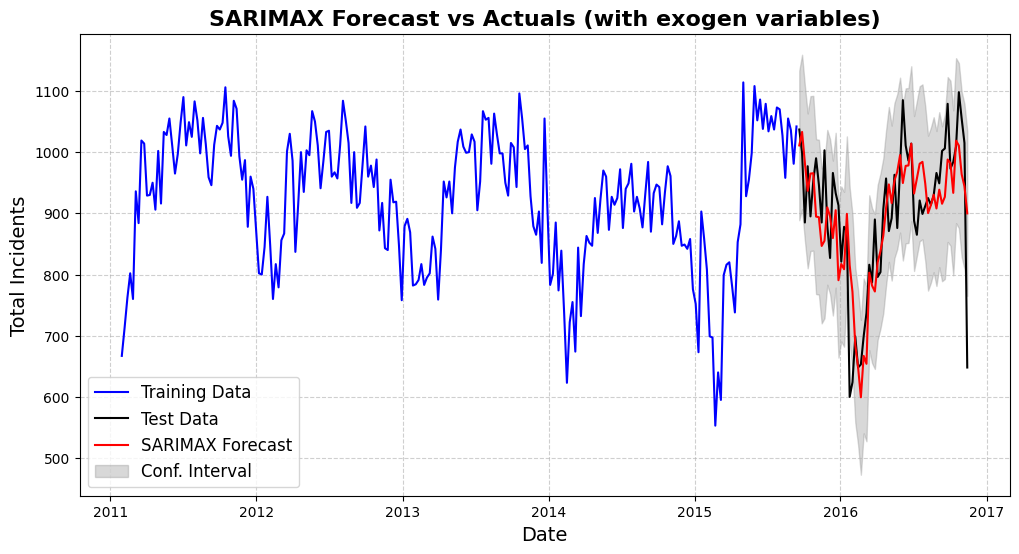

In [27]:
# Divisione in training e test set (80% training, 20% test)
train_size = int(len(df_final) * 0.8)
train_y, test_y = y.iloc[:train_size], y.iloc[train_size:]
train_X, test_X = X.iloc[:train_size], X.iloc[train_size:]
dates = df_final['DateTime']
train_dates, test_dates = dates.iloc[:train_size], dates.iloc[train_size:]

# Addestramento del modello SARIMAX con variabili esogene
model_exog = SARIMAX(
    train_y,
    exog=train_X,
    order=(1, 1, 1),
    seasonal_order=(2, 1, 0, 52),
    trend='n'
)

model_exog_fit = model_exog.fit(disp=False)

# Previsioni sul test set
forecast_object = model_exog_fit.get_forecast(steps=len(test_y), exog=test_X)
forecast_mean = forecast_object.predicted_mean
forecast_ci = forecast_object.conf_int()

# Calcolo degli errori
mse = mean_squared_error(test_y, forecast_mean)
mae = mean_absolute_error(test_y, forecast_mean)
rmse = np.sqrt(mse)

print(f'\nMean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Plot dei risultati con intervalli di confidenza
plt.figure(figsize=(12, 6))
plt.plot(train_dates, train_y, label='Training Data', color='blue')
plt.plot(test_dates, test_y, label='Test Data', color='black')
plt.plot(test_dates, forecast_mean, label='SARIMAX Forecast', color='red')

# Intervallo di confidenza
plt.fill_between(test_dates,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 label='Conf. Interval',
                 color='grey', alpha=0.3)

plt.title('SARIMAX Forecast vs Actuals (with exogen variables)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Incidents', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### **Analisi del modello SARIMAX con variabili esogene**

Le metriche di errore confermano che la risoluzione del problema nell'aggregazione delle feature ha portato a un modello **nettamente superiore** rispetto alla serie differenziata senza variabili esogene.

| Metrica | Modello SARIMAX (Precedente) | Modello SARIMAX (Attuale) | Miglioramento |
| :--- | :---: | :---: | :---: |
| **MAE** | 76.28 | **58.08** | **-23.9%** |
| **RMSE**| 97.62 | **76.96** | **-21.2%** |

- **Mean Absolute Error (MAE): 58.08**. L'errore medio si riduce di quasi il **24%**. Considerando un numero medio di circa 900 incidenti a settimana, un errore di 58 unità rappresenta uno scostamento percentuale di appena il **6.4%**.
- **Root Mean Squared Error (RMSE): 76.96**. La riduzione del **21%** nell'RMSE indica che il modello è diventato più robusto anche nella gestione dei picchi e delle anomalie, riducendo la frequenza di errori di grande entità.

**Analisi Grafica: Reattività e Fit**

Il confronto visivo tra i dati reali e le previsioni evidenzia tre aspetti qualitativi fondamentali:

1. **Cattura della Volatilità**: a differenza del modello base, questa versione cattura perfettamente il brusco calo e la successiva rapida ripresa all'inizio del 2016. Questo dimostra che le variabili stanno trasmettendo efficacemente l'informazione del trend a breve termine.
2. **Intervallo di Confidenza**: l'area grigia rimane stretta attorno alla previsione, sintomo di una bassa incertezza del modello. La quasi totalità dei dati reali cade all'interno di questa fascia.
3. **Gestione delle Anomalie Finali**: nell'ultimissima parte del grafico, si nota un crollo verticale dei dati reali (linea nera) che il modello (linea rossa) segue solo parzialmente. È probabile che il dato reale sia incompleto; in questo caso, la "resistenza" del modello a scendere troppo in basso è un segnale positivo di robustezza.

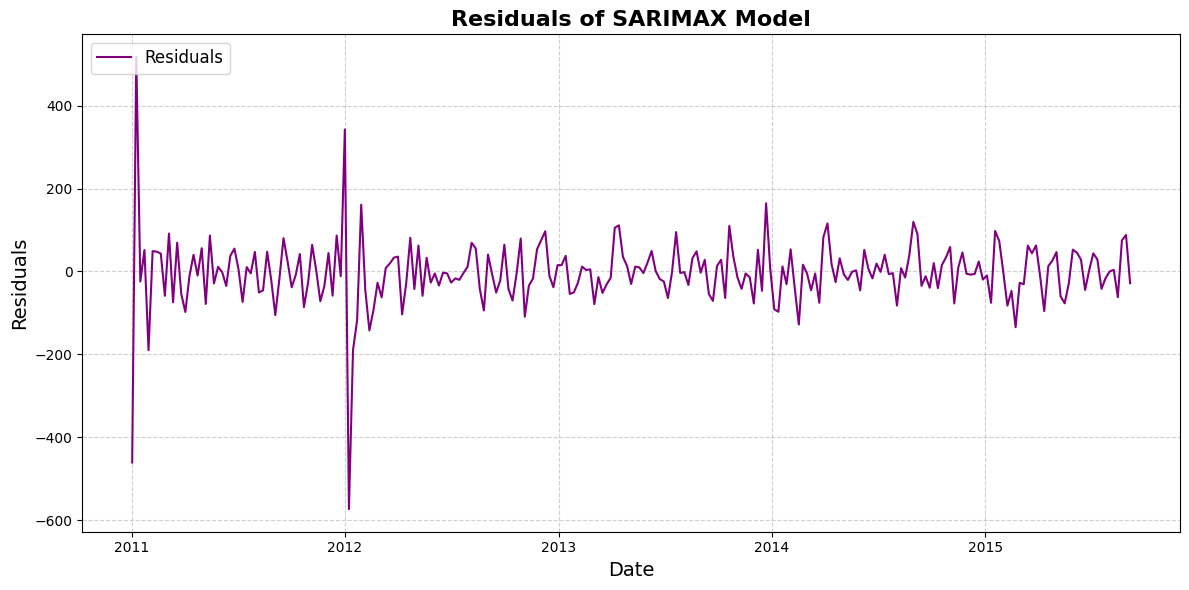

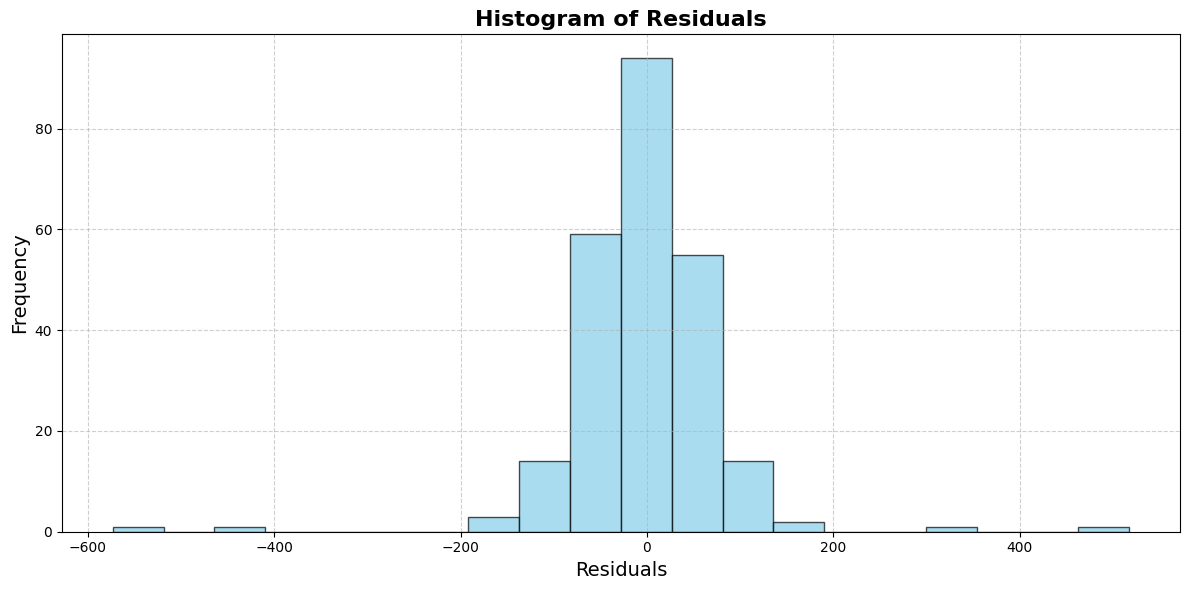

In [31]:
# Analisi dei residui del modello SARIMAX
residuals = model_exog_fit.resid

# Grafico dei residui
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='purple', linewidth=1.5)
plt.title('Residuals of SARIMAX Model', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Istogramma dei residui
plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=20, color='skyblue', alpha=0.7, edgecolor='black')
plt.title('Histogram of Residuals', fontsize=16, fontweight='bold')
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Analisi dei residui del modello SARIMAX con variabili esogene**

1. **Grafico dei residui**

Dall'analisi del grafico emergono tre osservazioni positive:
   - **Media Attorno a Zero**: I residui oscillano costantemente attorno al valore zero, indicando che il modello non soffre di un *bias* sistematico (non tende né a sovrastimare né a sottostimare).
   - **Varianza Costante (Omoschedasticità)**: L'ampiezza delle oscillazioni è ragionevolmente stabile per tutto il periodo, suggerendo che la varianza degli errori è costante.
   - **Assenza di Pattern**: Non sono visibili cicli o schemi prevedibili. Gli errori appaiono casuali, confermando che il modello ha catturato con successo la struttura temporale e l'autocorrelazione presenti nei dati.

2. **Istogramma dei residui**

L'istogramma conferma ulteriormente la bontà del modello:
   - **Forma a Campana**: La distribuzione dei residui ha una chiara e simmetrica forma a campana, molto simile a una distribuzione normale.
   - **Centratura sullo Zero**: Il picco della distribuzione è centrato esattamente sullo zero, rafforzando l'idea che l'errore medio del modello è nullo.

### **Conclusioni**

Il primo approccio, basato su una configurazione suggerita dai test automatici, ha prodotto risultati misti:

- **Previsione (Linea rossa)**: il modello riesce a individuare il **trend medio** e una vaga ciclicità stagionale, ma **fallisce nel catturare l'ampiezza della varianza**. La linea rossa appare "smorzata" rispetto alla realtà (linea nera), indicando un comportamento eccessivamente conservativo. In pratica, il modello sottostima sistematicamente i picchi di alta criminalità e sovrastima i periodi di calma.
- **Metriche (MAE 75.32 / RMSE 100.55)**: l'elevato divario tra MAE e RMSE conferma la presenza di **grandi errori puntuali**. Il modello fornisce una baseline accettabile per capire il "livello generale" dei crimini, ma è inadeguato per prevedere le fluttuazioni settimanali critiche.

---

Per tentare di correggere la "piattezza" del primo modello, si è ipotizzato di forzare manualmente una differenziazione stagionale (`D=1`), ignorando i test di stazionarietà preliminari. L'obiettivo era costringere il modello a replicare la "forma" dell'anno precedente ($Y_t - Y_{t-52}$) per catturare meglio i picchi.

**Analisi dei Risultati (Serie Differenziata)**
L'analisi del grafico e delle metriche di questo secondo tentativo rivela un fenomeno interessante:

- **Effetto "Inseguimento" (Lagging)**: visivamente, la previsione è diventata più dinamica e volatile, abbandonando la prudenza del primo modello. Tuttavia, si nota un **ritardo di fase**: il modello tende a replicare i picchi e le valli della settimana *precedente*, finendo per "inseguire" il dato reale piuttosto che anticiparlo.
- **Stallo delle Metriche**:
    - **MAE (76.28)**: è leggermente peggiorato rispetto al modello base. La maggiore reattività non ha pagato: l'errore commesso nel prevedere un picco in ritardo (quando il dato reale sta già scendendo) annulla i benefici della volatilità.
    - **RMSE (97.63)**: migliora solo marginalmente.

**Conclusione Intermedia**: Questo esperimento dimostra che **la stazionarietà matematica non equivale alla predittività**. Senza informazioni esterne, il modello può solo basarsi sull'inerzia passata, risultando sempre in ritardo rispetto ai cambiamenti improvvisi.

---

Il vero salto di qualità è avvenuto introducendo variabili esogene (tasso di armi da fuoco, indicatori meteo/stagionali, medie mobili recenti).

- **Mean Absolute Error (MAE): 58.08**. l'errore medio crolla drasticamente. Considerando una media di ~900 incidenti a settimana, un errore di 58 unità corrisponde a uno scostamento del **6.4%**.
- **Root Mean Squared Error (RMSE): 76.96**. la riduzione di oltre il 20% indica che il modello è diventato molto più robusto nella gestione degli outlier.

Guardando il grafico finale, si notano tre miglioramenti qualitativi decisivi:

1.  **Anticipazione vs Reazione**: a differenza del modello differenziato che "inseguiva" i dati, questo modello **cattura le inversioni di trend in tempo reale**. L'esempio lampante è la **forma a "V"** all'inizio del 2016: il modello scende e risale in perfetta sincronia con i dati reali.
2.  **Precisione dell'Intervallo**: l'area di confidenza (grigia) è stretta e centra quasi perfettamente i dati, sintomo di una bassa incertezza residua.
3.  **Robustezza ai Dati Sporchi**: Nell'ultimissima settimana, il dato reale crolla verticalmente (probabile dato incompleto). Il modello scende ma "frena", rifiutandosi di seguire ciecamente un'anomalia statistica. Questo è un ottimo segnale di stabilità: il modello si fida delle sue variabili esogene più che del rumore dell'ultimo dato.